# MACD Momentum Pullback Strategy
# max stocks: 15
# Price Bracket: 90- 600
# max year: 1
# DATA_DIR = 'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
# Seed : 5

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(5) 
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 15: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        
        df = df.sort_values('Date').reset_index(drop=True)
        if len(df) < 300: # Need enough history
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks for MACD analysis.")


Loaded 15 stocks for MACD analysis.


In [3]:
# 3. Strategy Backtest: The MACD Pullback
trades = []
enriched_data = []

symbols = data['Symbol'].unique()

for symbol in symbols:
    df = data[data['Symbol'] == symbol].copy()
    
    # Calculate MACD
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Hist'] = df['MACD'] - df['Signal']
    
    # Filter to last 250 days for backtest and plotting
    if len(df) > 250:
        df = df.tail(250).reset_index(drop=True)
    
    # Trend: MACD and Signal must be > 0 (Macro Uptrend)
    df['Trend_Up'] = (df['MACD'] > 0) & (df['Signal'] > 0)
    
    # Setup: Histogram is negative (Short-term Pullback)
    df['Setup'] = df['Hist'] < 0
    
    # Entry Trigger: Histogram ticks UP (momentum shifting back to buyers)
    df['Cross_Up'] = df['Hist'] > df['Hist'].shift(1)
    
    df['Buy_Signal'] = df['Trend_Up'] & df['Setup'] & df['Cross_Up']
    
    in_trade = False
    entry_price = 0
    entry_date = None
    
    for i, row in df.iterrows():
        if not in_trade and row['Buy_Signal']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
        
        elif in_trade:
            current_price = row['Close']
            current_date = row['Date']
            profit_pct = (current_price - entry_price) / entry_price
            days_held = (current_date - entry_date).days
            
            # Exit Conditions: +5% TP, -3% SL
            if profit_pct >= 0.05 or profit_pct <= -0.03:
                in_trade = False
                trades.append({
                    'Symbol': symbol,
                    'Entry_Date': entry_date,
                    'Exit_Date': current_date,
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'Profit_Pct': profit_pct * 100,
                    'Days_Held': days_held,
                    'Exit_Reason': 'Take Profit (+5%)' if profit_pct > 0 else 'Stop Loss (-3%)'
                })
                
    enriched_data.append(df)

data = pd.concat(enriched_data, ignore_index=True)
trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    total_trades = len(trades_df)
    winners = trades_df[trades_df['Profit_Pct'] > 0]
    losers = trades_df[trades_df['Profit_Pct'] <= 0]
    
    win_rate = len(winners) / total_trades * 100
    avg_win = winners['Profit_Pct'].mean() if len(winners) > 0 else 0
    avg_loss = losers['Profit_Pct'].mean() if len(losers) > 0 else 0
    
    exit_reasons = trades_df['Exit_Reason'].value_counts(normalize=True) * 100
    
    summary_html = f'''
    <h3>MACD Strategy Summary</h3>
    <ul>
        <li><b>Total Trades:</b> {total_trades}</li>
        <li><b>Win Rate:</b> {win_rate:.2f}%</li>
        <li><b>Average Win:</b> +{avg_win:.2f}%</li>
        <li><b>Average Loss:</b> {avg_loss:.2f}%</li>
    </ul>
    <h4>Exit Reasons</h4>
    <ul>
    '''
    for reason, pct in exit_reasons.items():
        summary_html += f"<li>{reason}: {pct:.1f}%</li>"
    summary_html += "</ul>"
    
    display(HTML(summary_html))
    
    display(HTML("<h3>Trade Ledger</h3>"))
    display(trades_df)
else:
    print("No trades triggered for these stocks in this 1-year window.")


,Symbol,Entry_Date,Exit_Date,Entry_Price,Exit_Price,Profit_Pct,Days_Held,Exit_Reason
0,SYNGENE,2025-08-13,2025-08-28,659.150024,629.200012,-4.543732,15,Stop Loss (-3%)
1,SYNGENE,2026-05-19,2026-05-29,471.350006,442.000000,-6.226797,10,Stop Loss (-3%)
2,NBCC,2025-10-01,2025-10-29,109.480003,115.220001,5.242965,28,Take Profit (+5%)
3,NBCC,2025-11-14,2025-12-08,114.139999,107.980003,-5.396878,24,Stop Loss (-3%)
4,NBCC,2026-05-21,2026-05-27,93.070000,99.099998,6.478993,6,Take Profit (+5%)
5,NAZARA,2025-08-04,2025-08-20,340.500000,304.850006,-10.469895,16,Stop Loss (-3%)
6,NAZARA,2026-01-21,2026-02-06,277.149994,259.000000,-6.548798,16,Stop Loss (-3%)
7,NAZARA,2026-02-09,2026-03-02,272.450012,257.500000,-5.487250,21,Stop Loss (-3%)
8,NAZARA,2026-05-06,2026-05-12,271.799988,263.100006,-3.200876,6,Stop Loss (-3%)
9,NAZARA,2026-06-05,2026-06-12,271.500000,285.850006,5.285453,7,Take Profit (+5%)


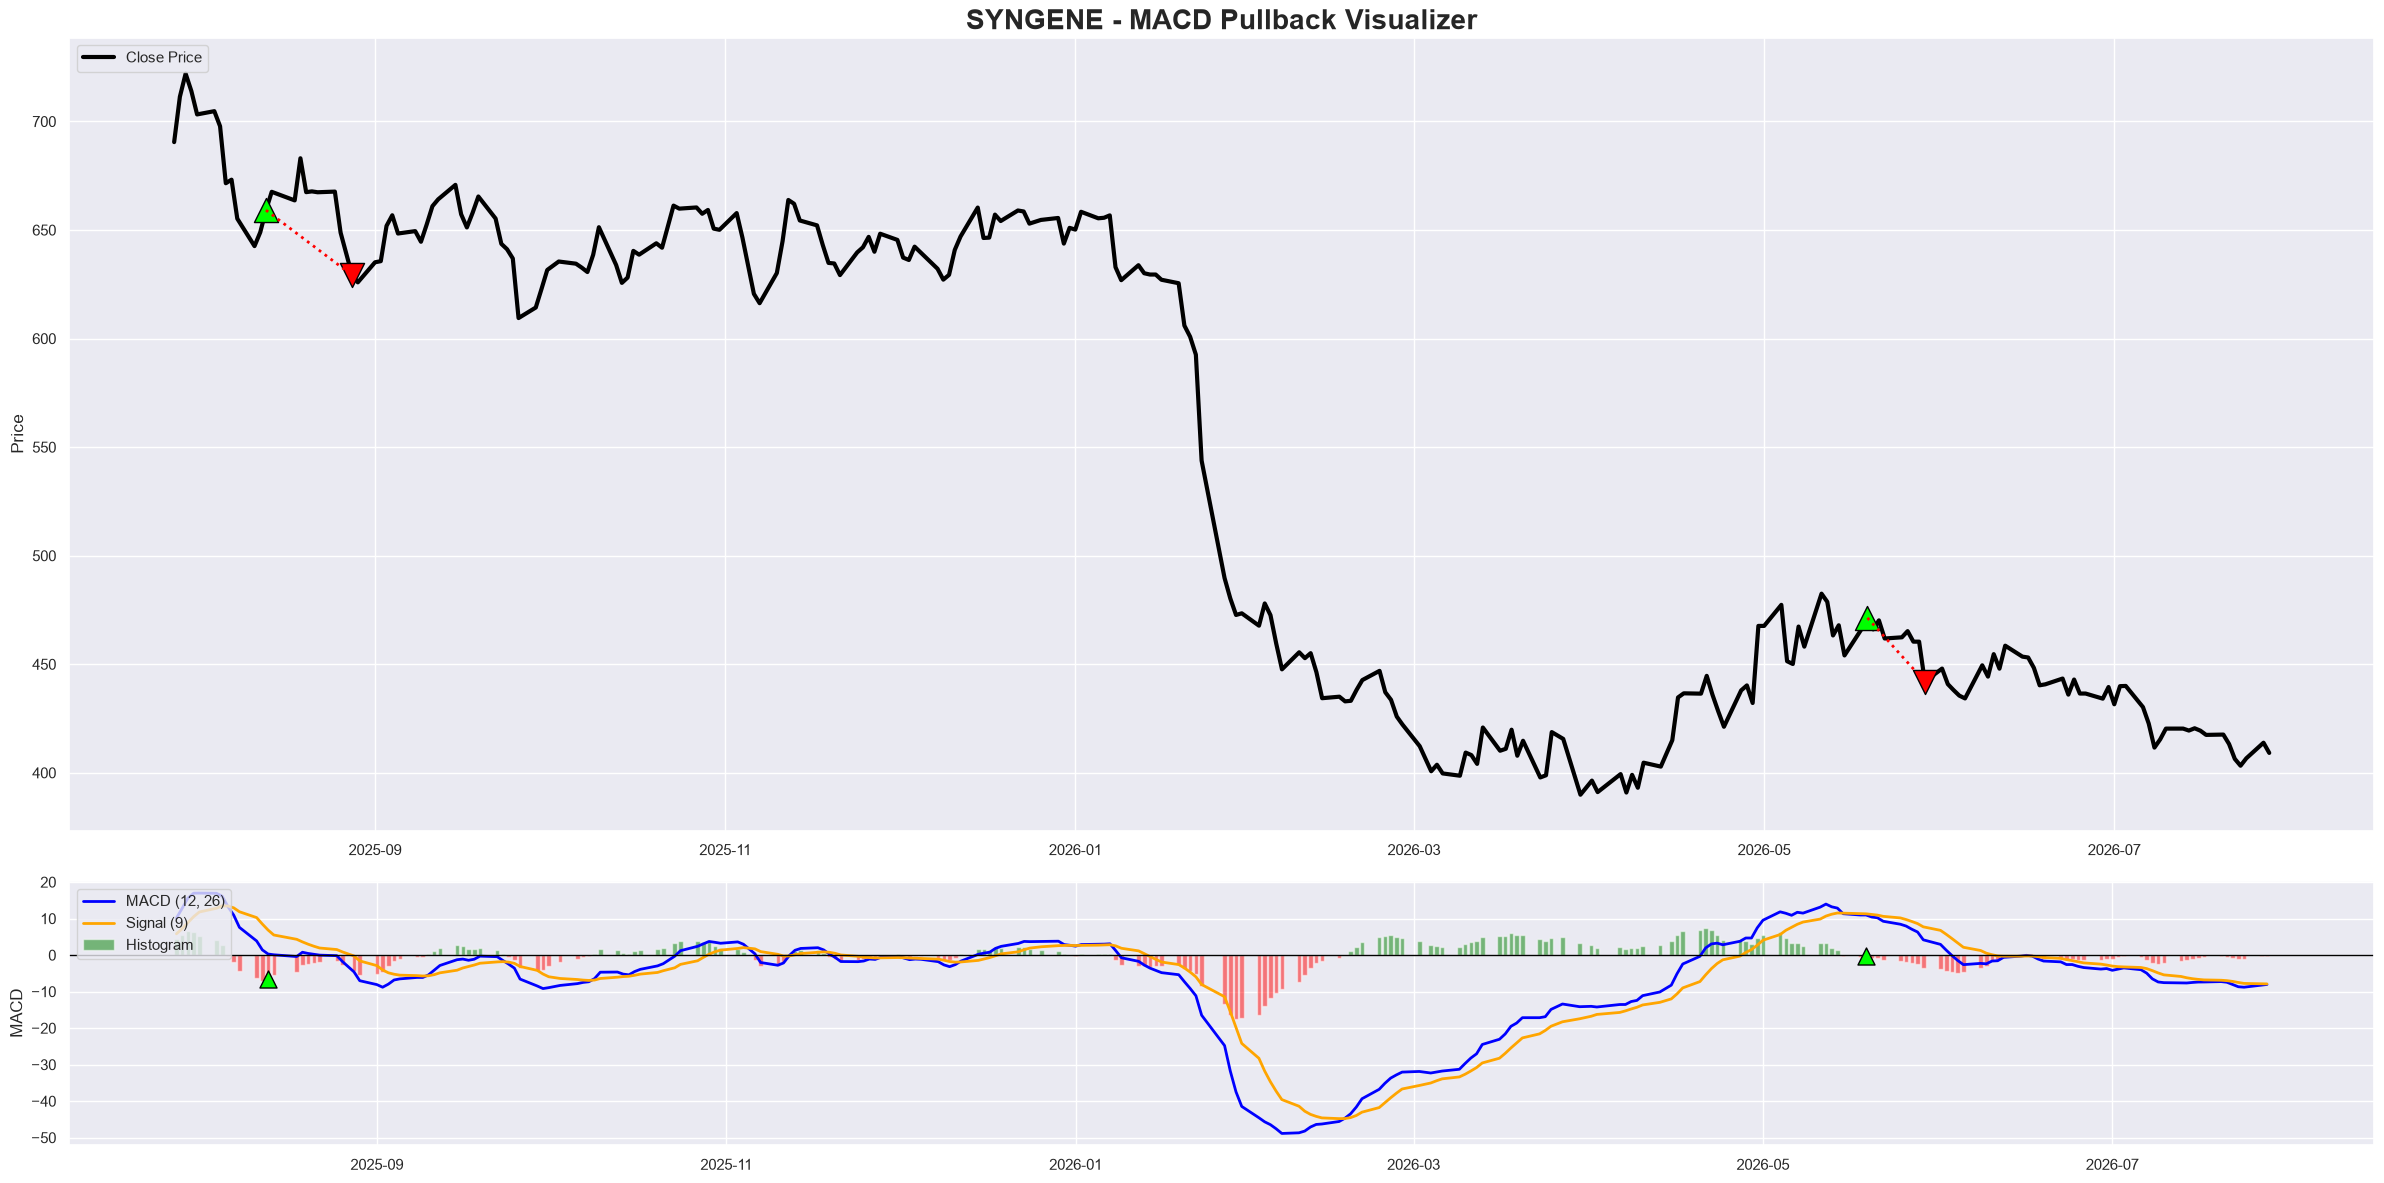

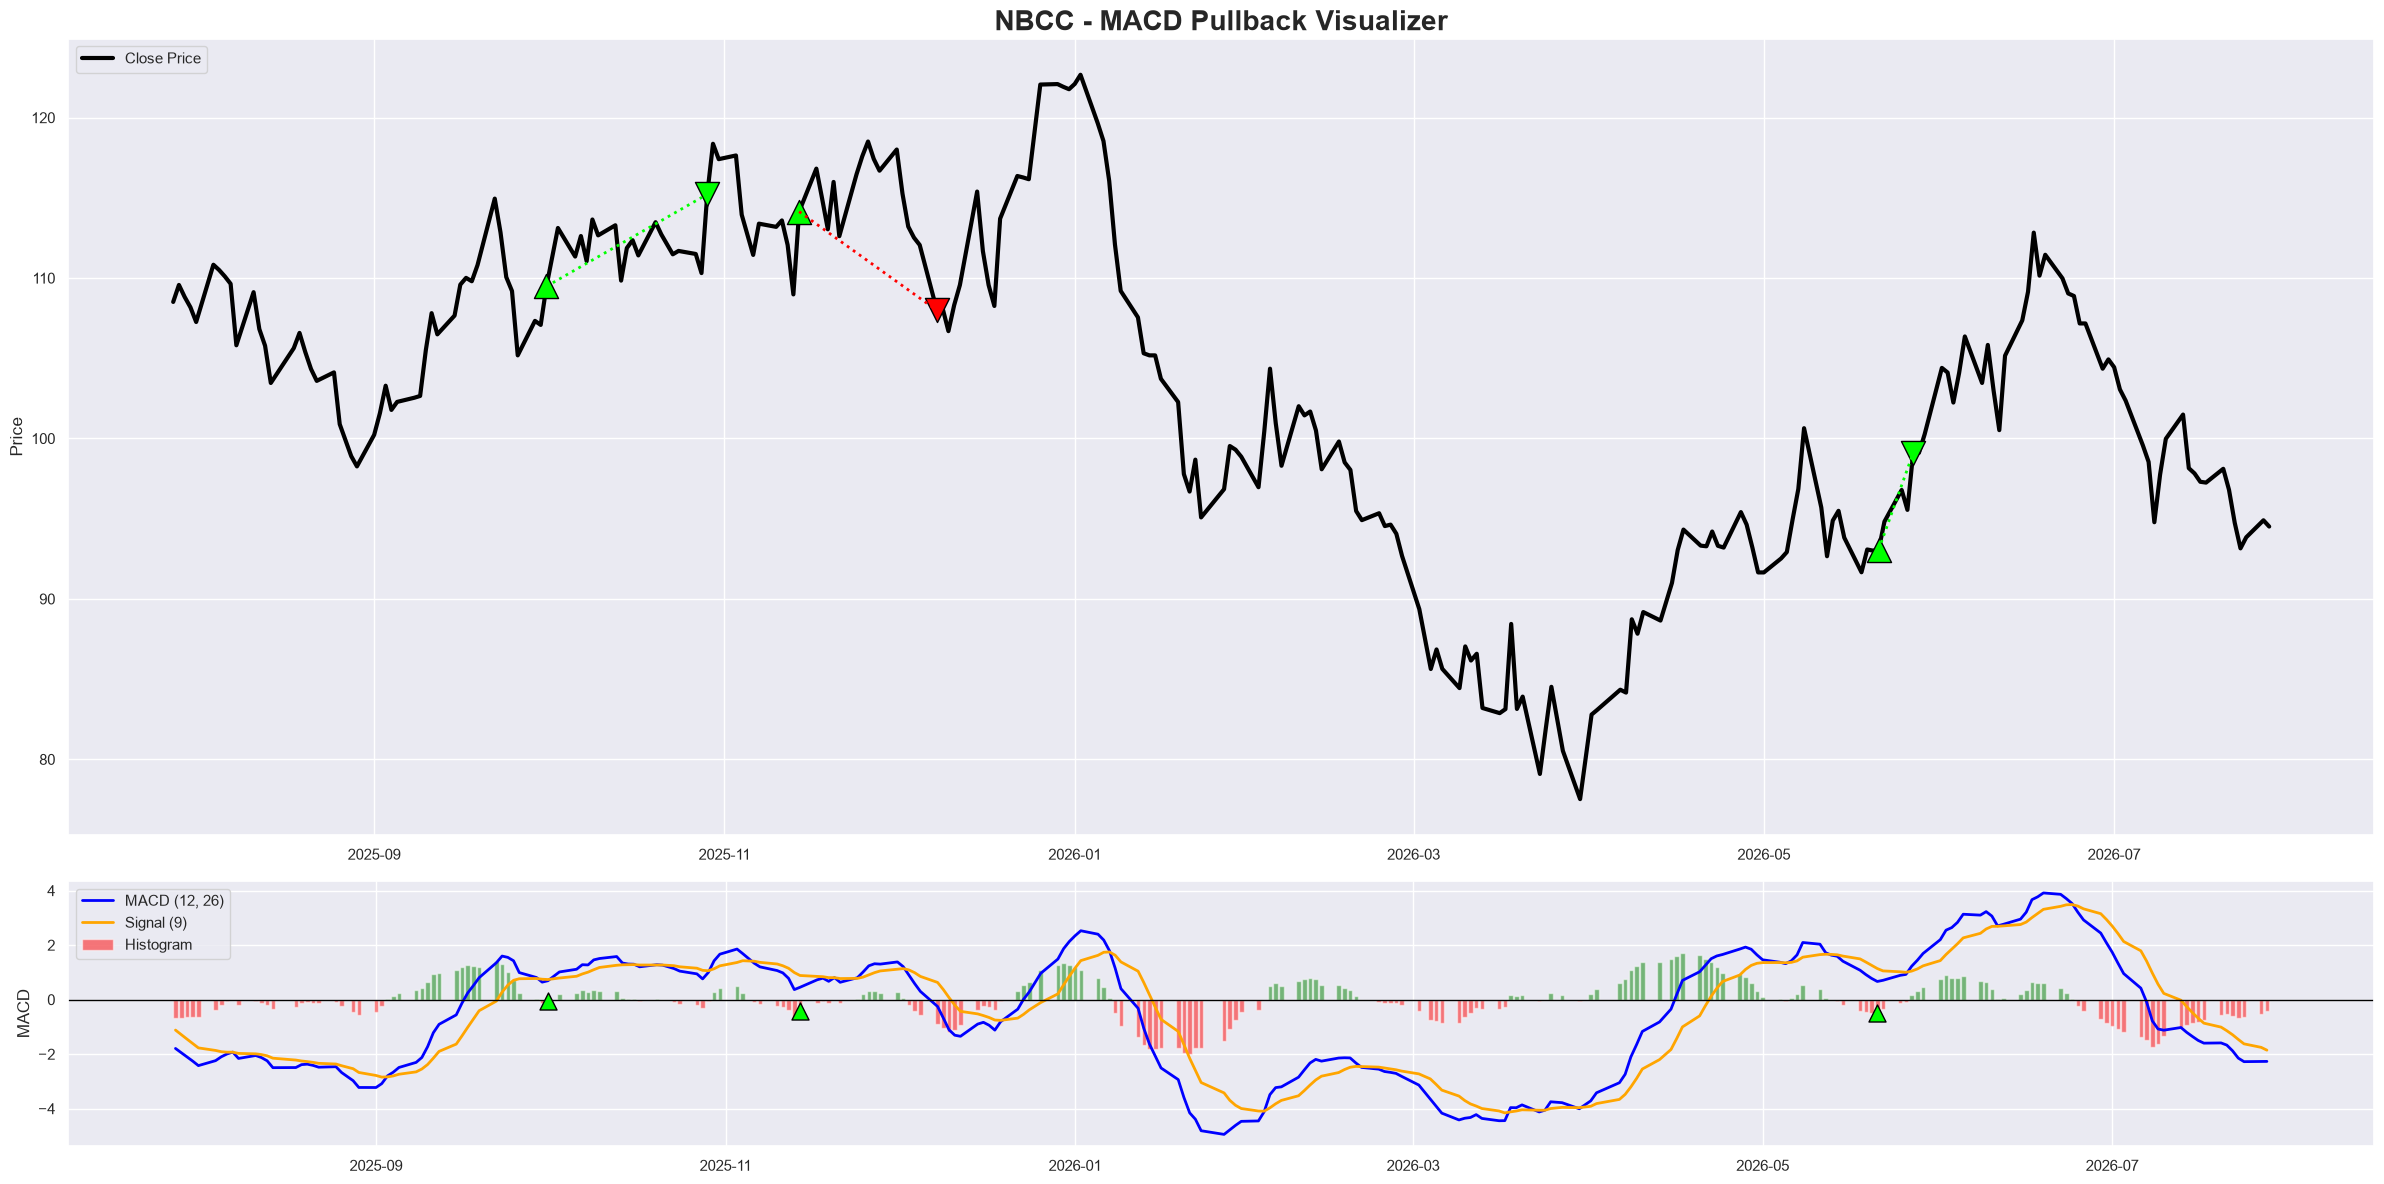

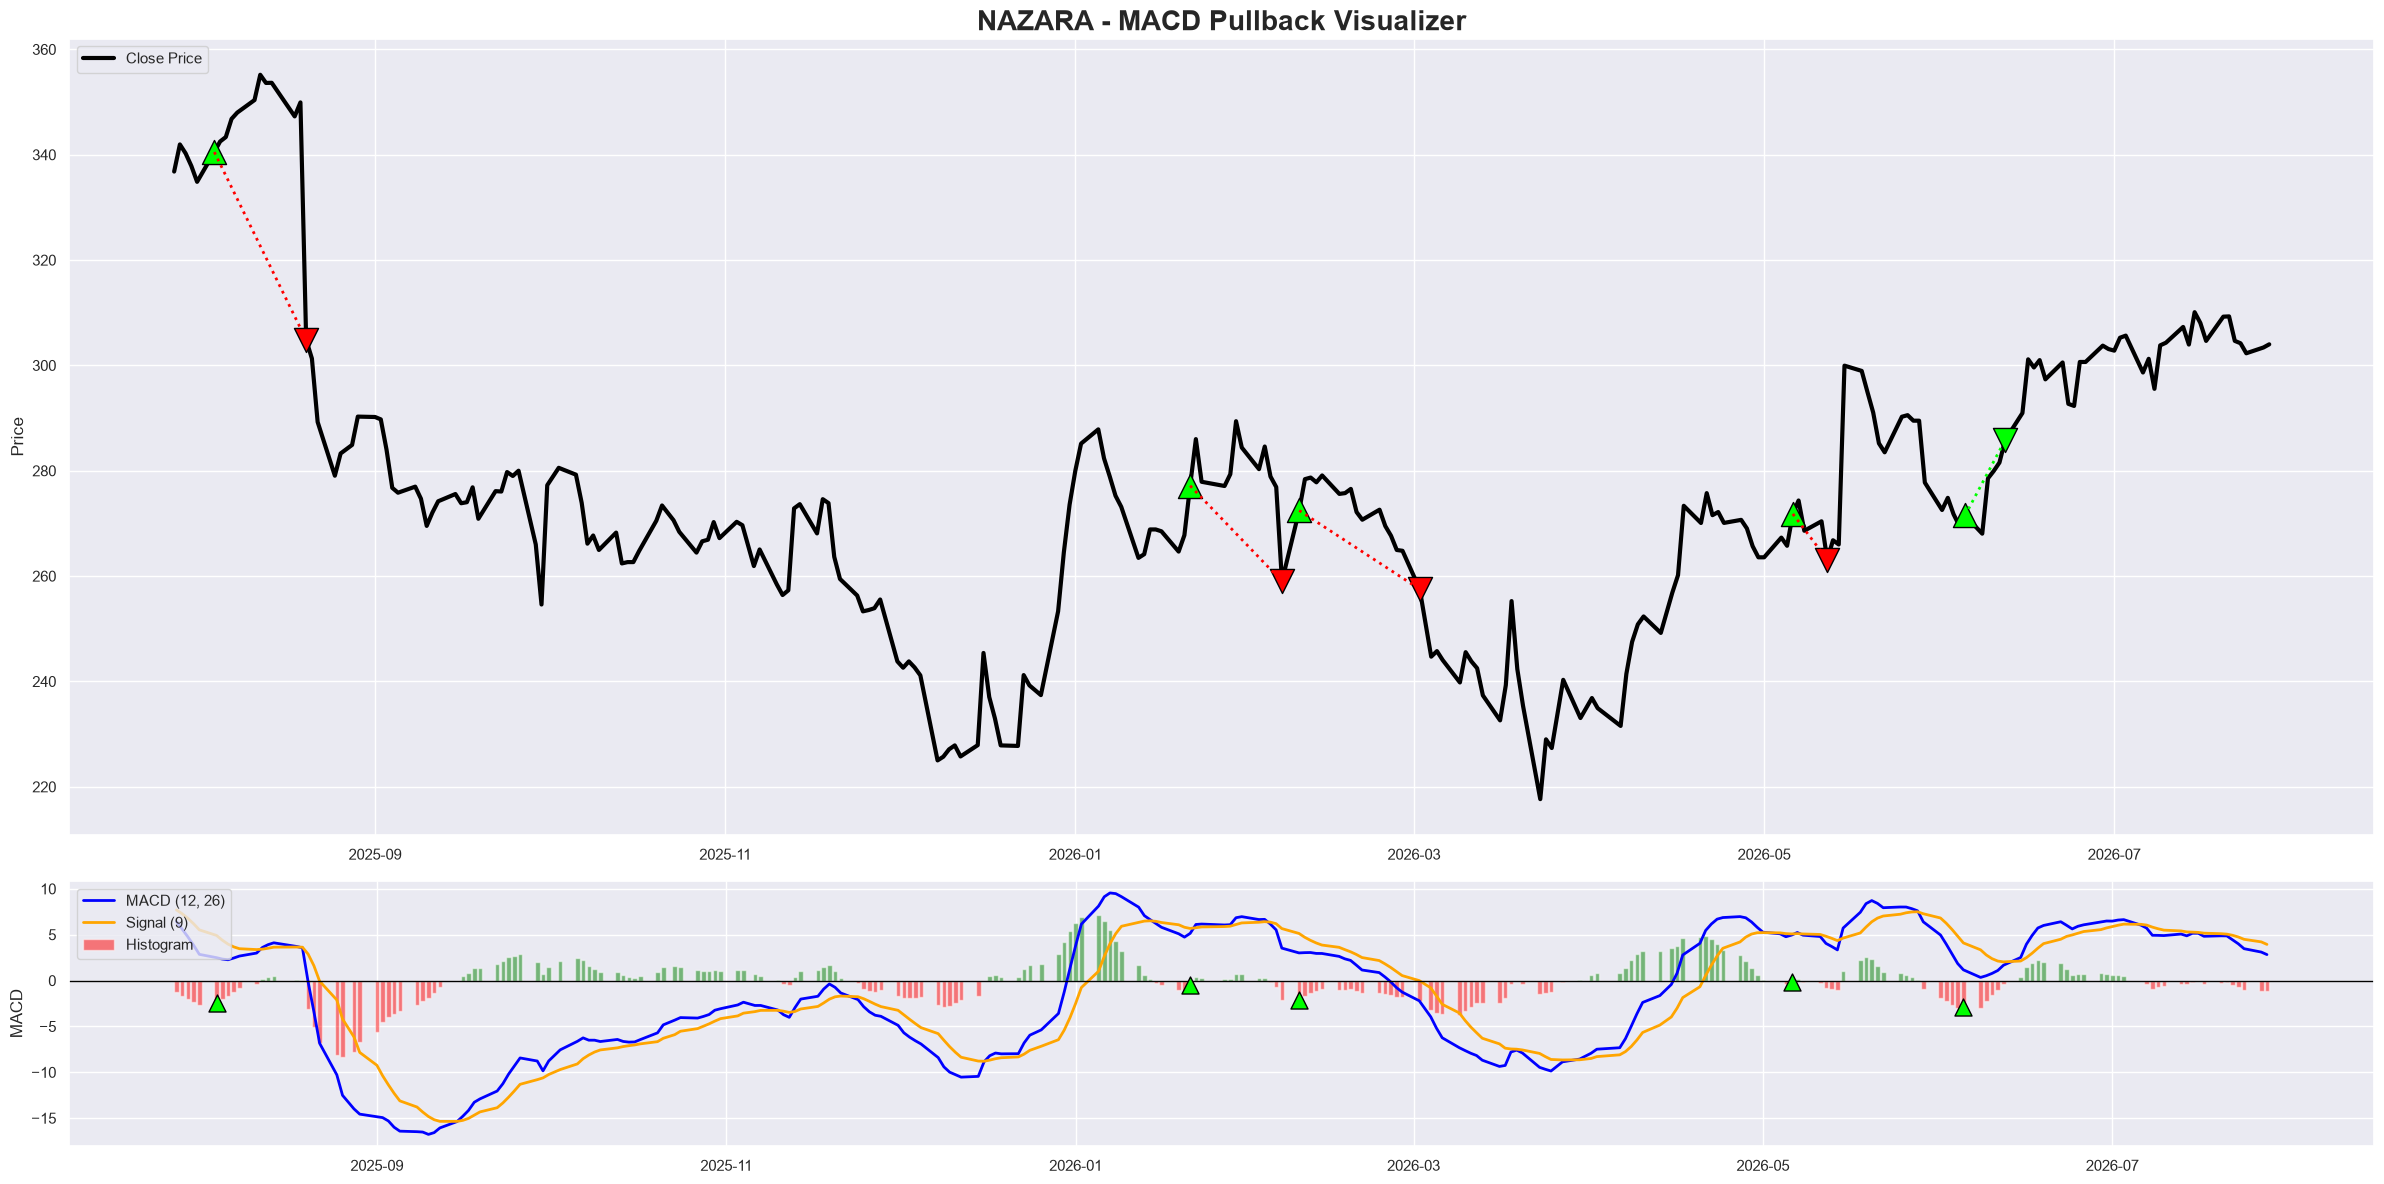

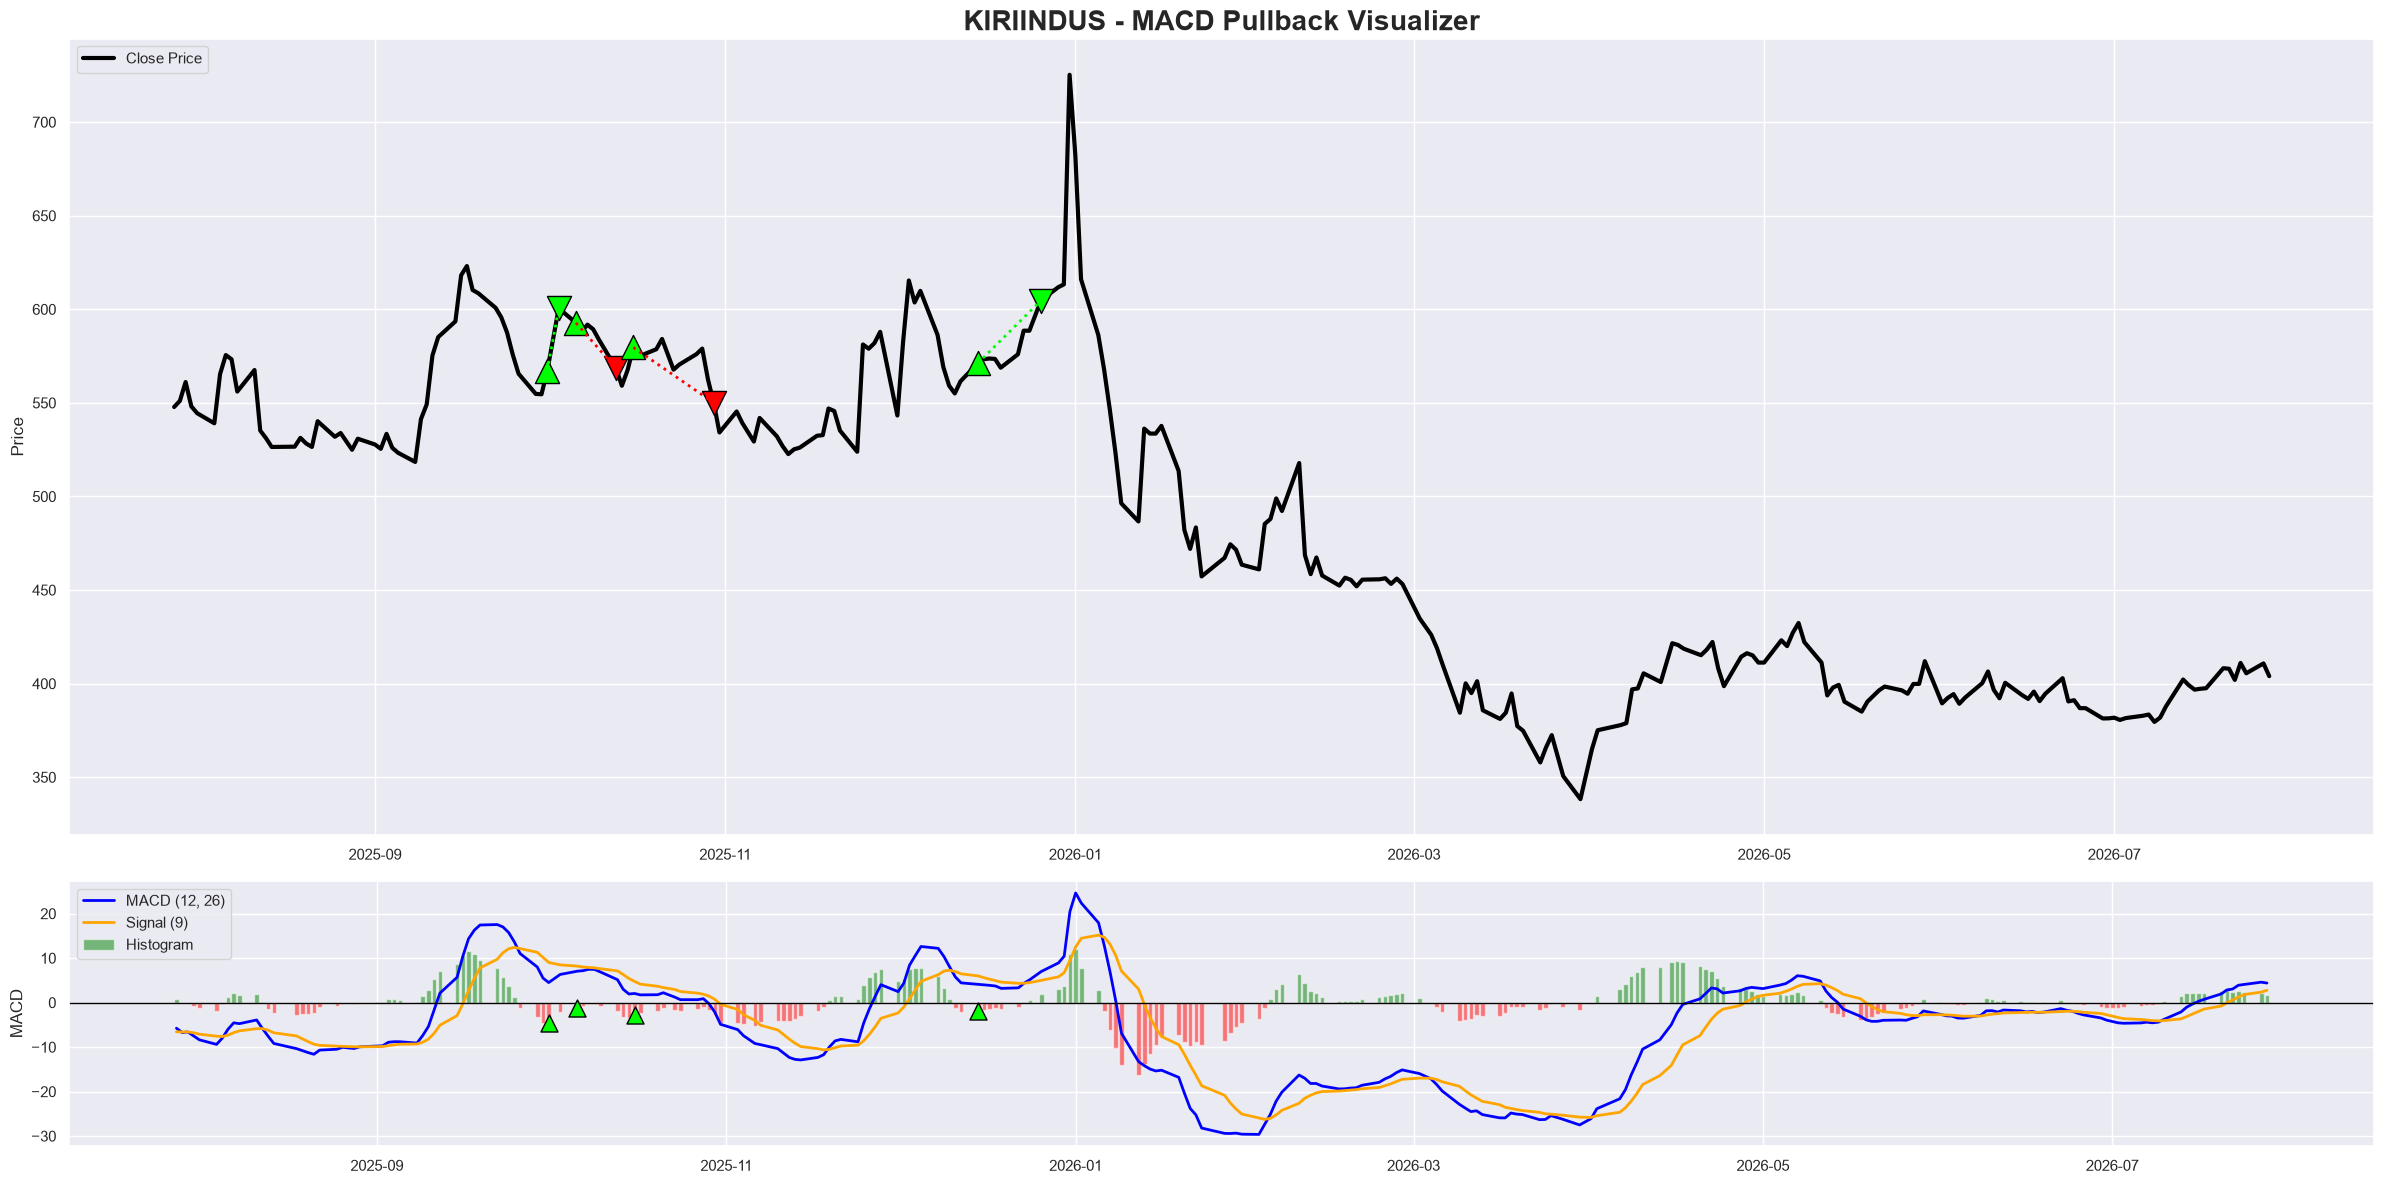

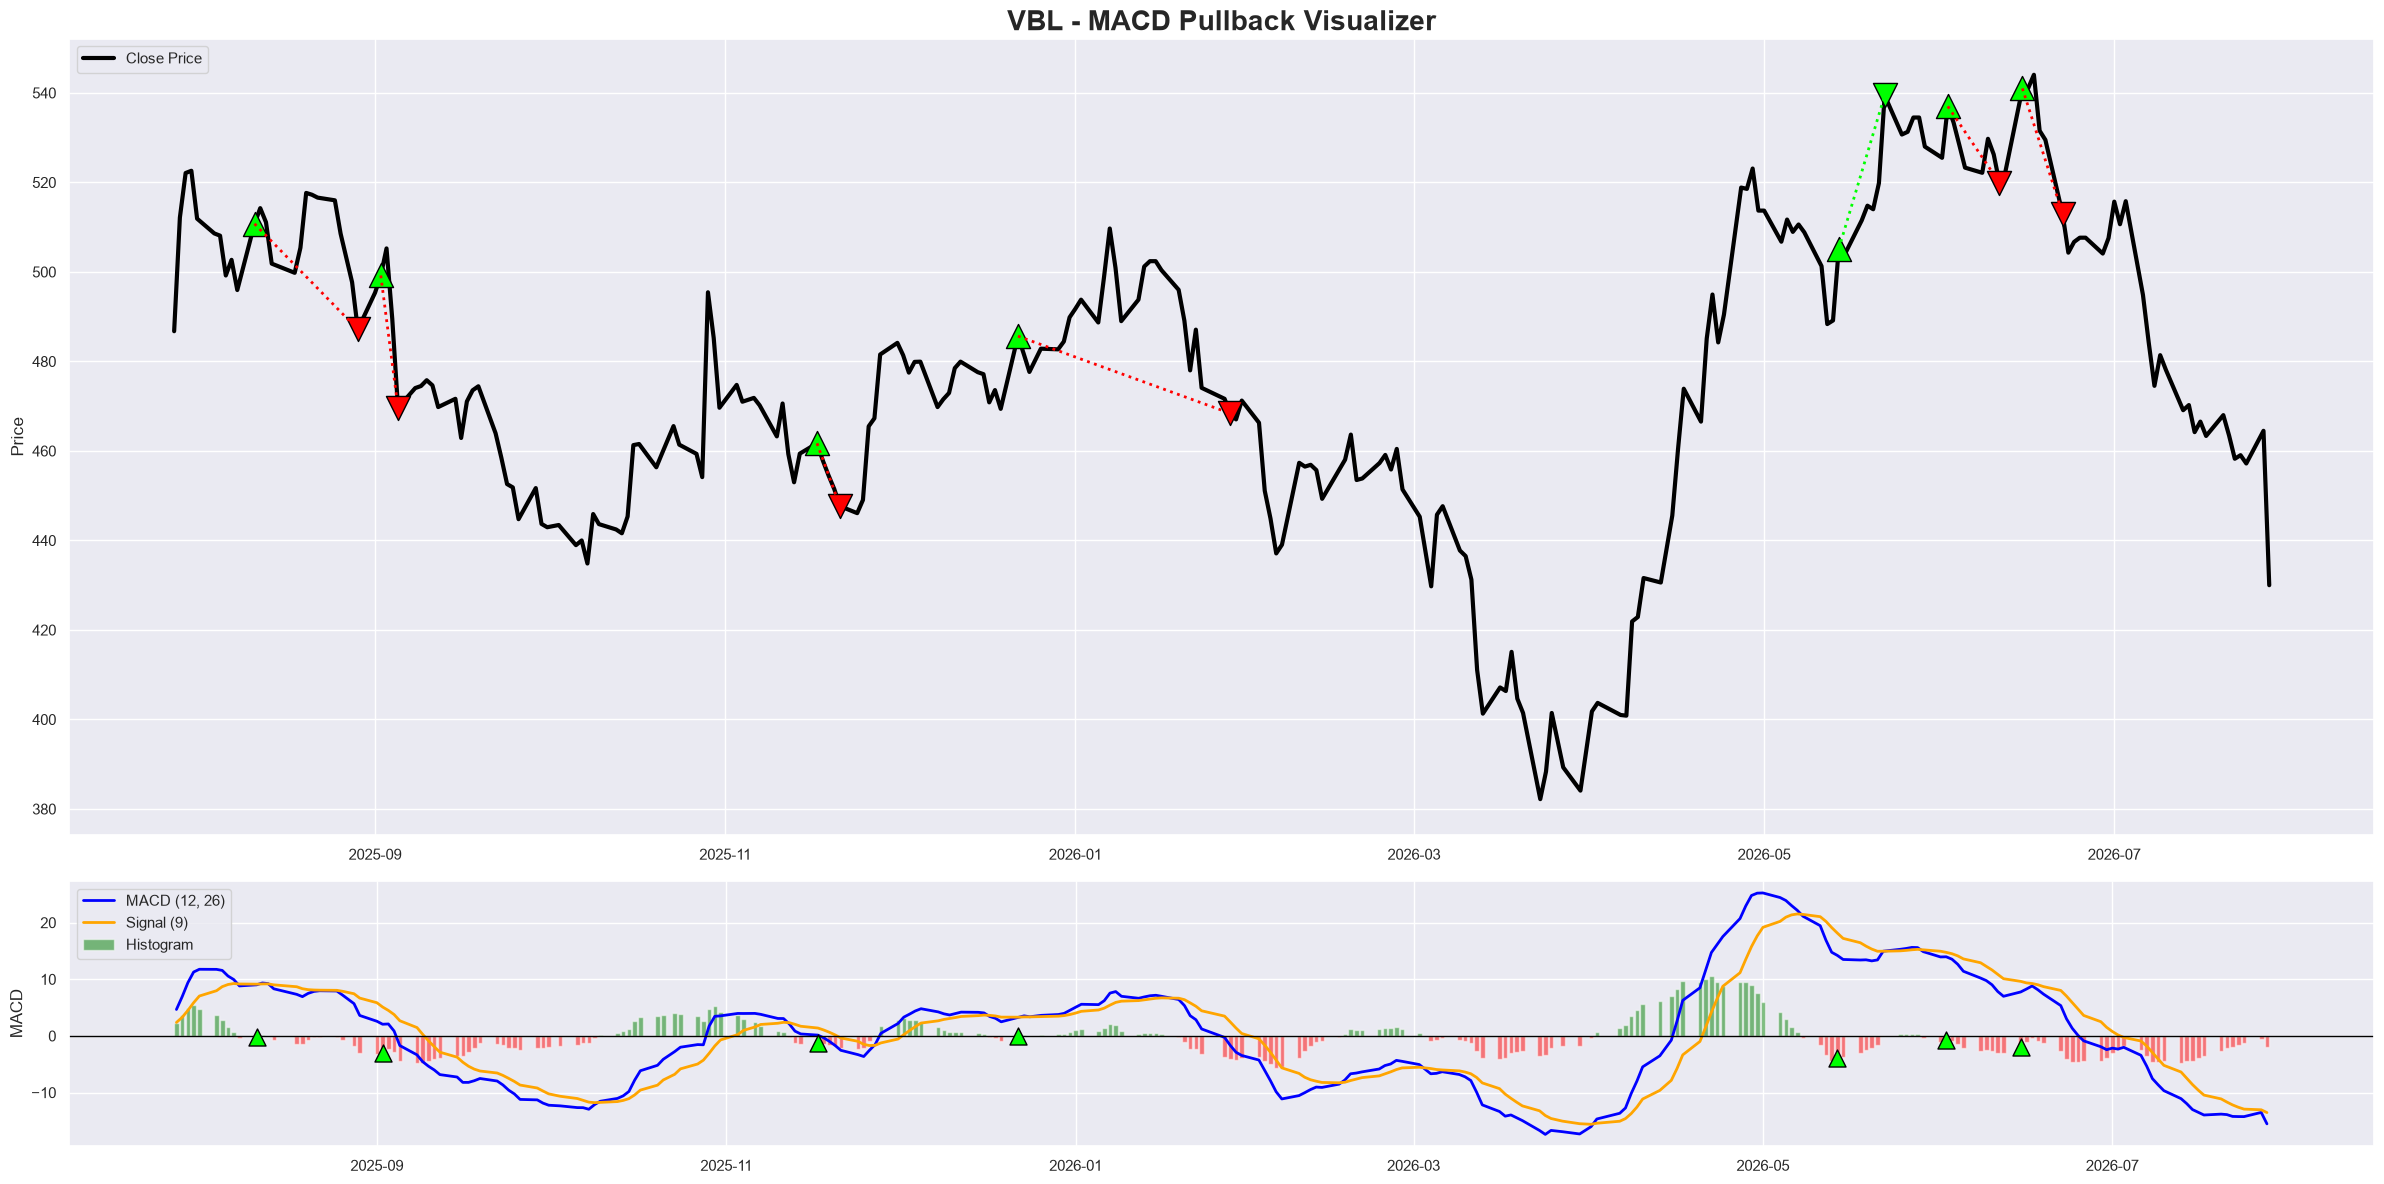

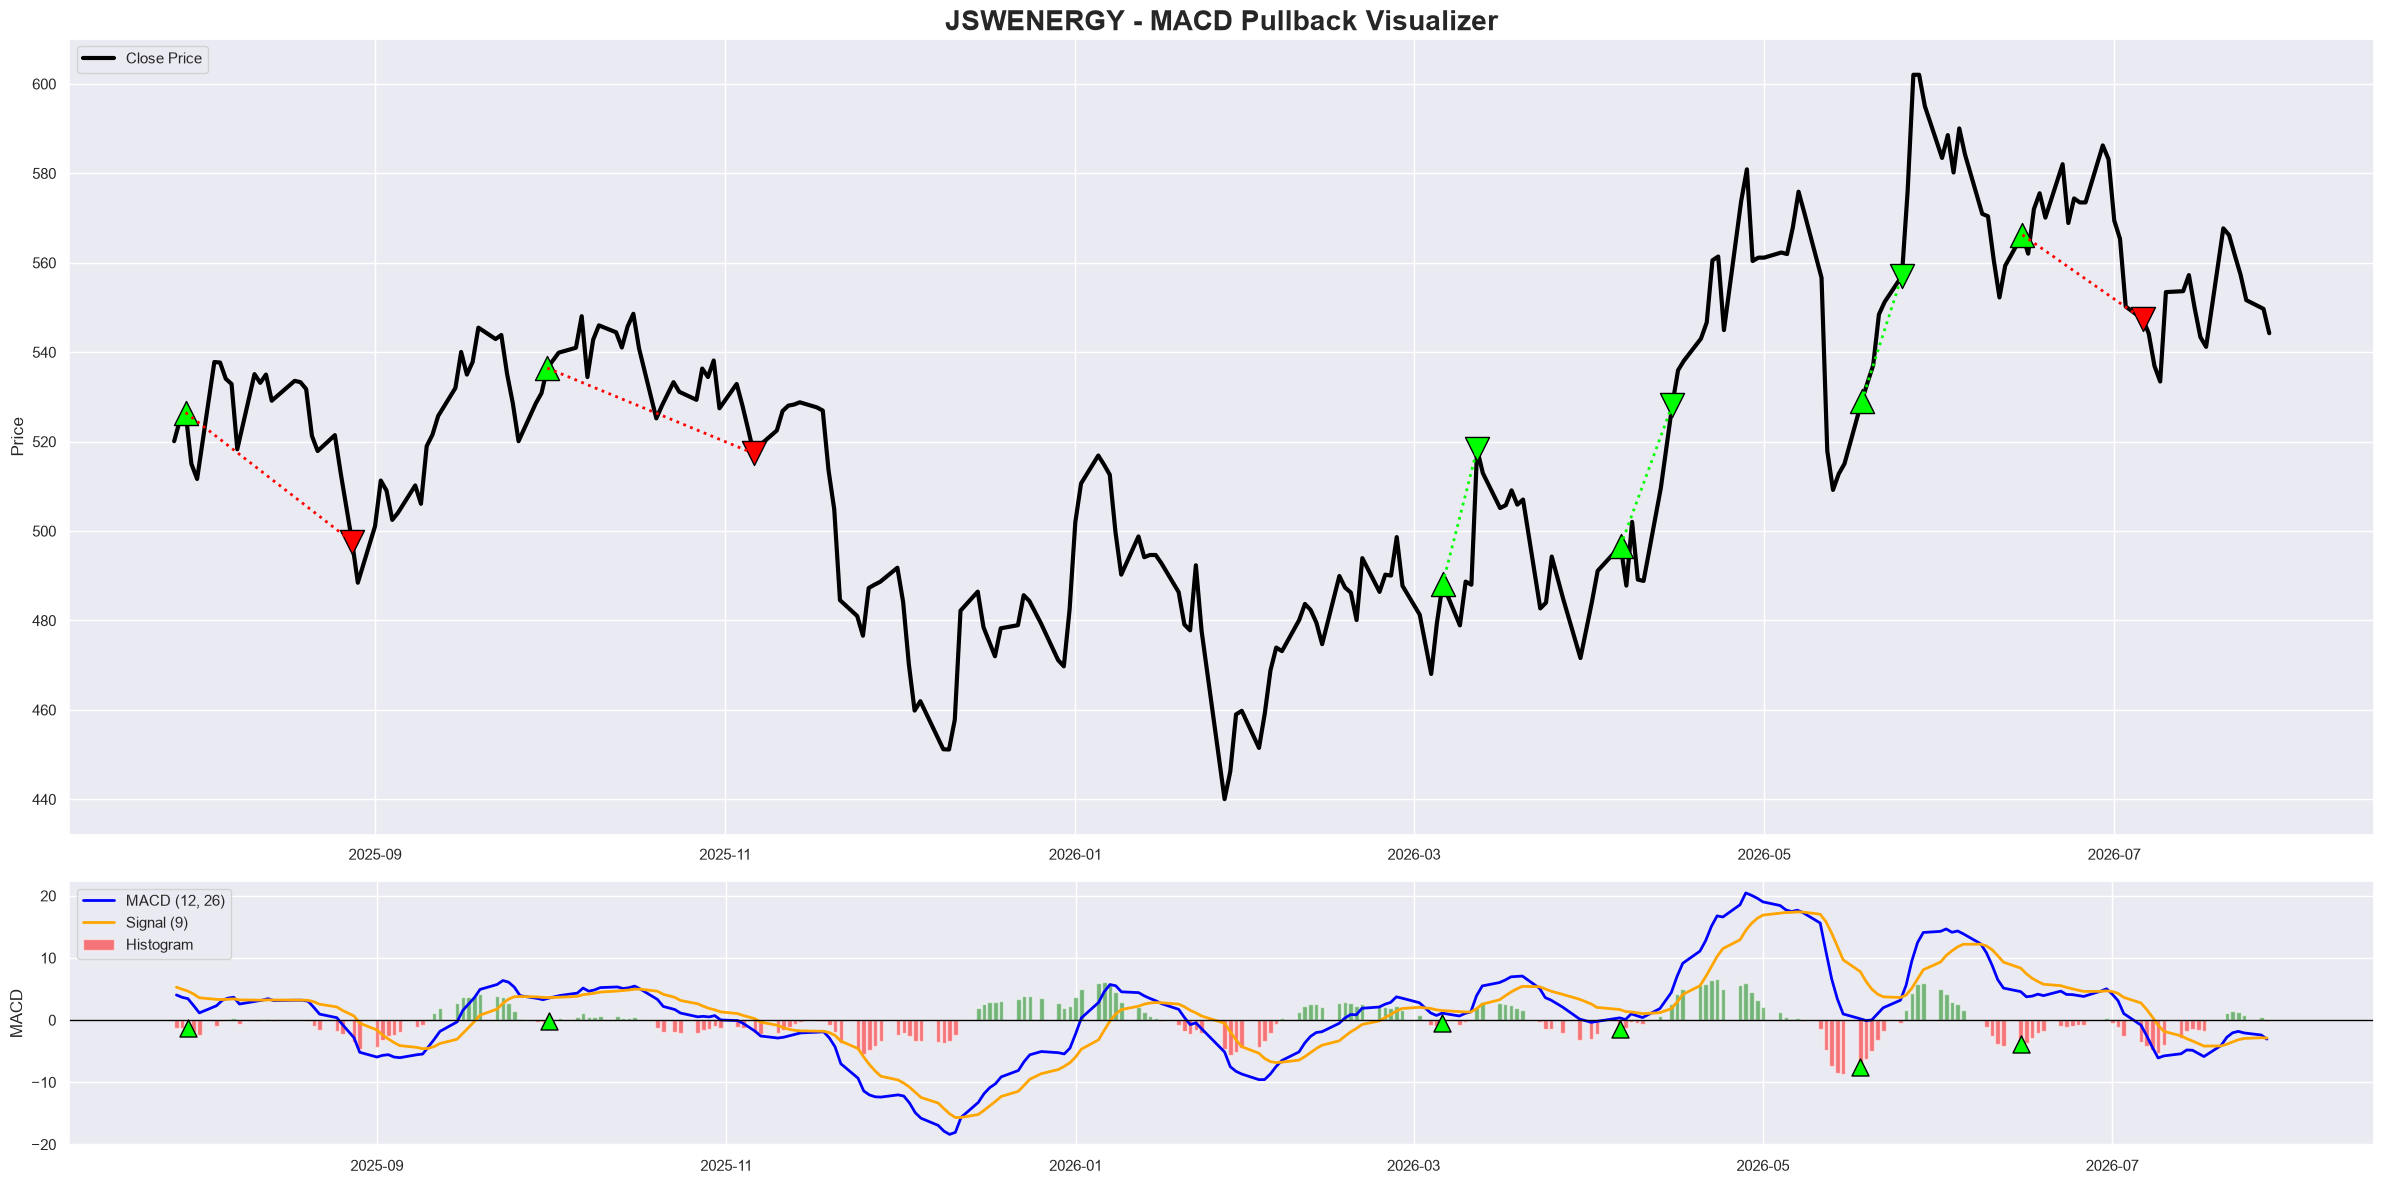

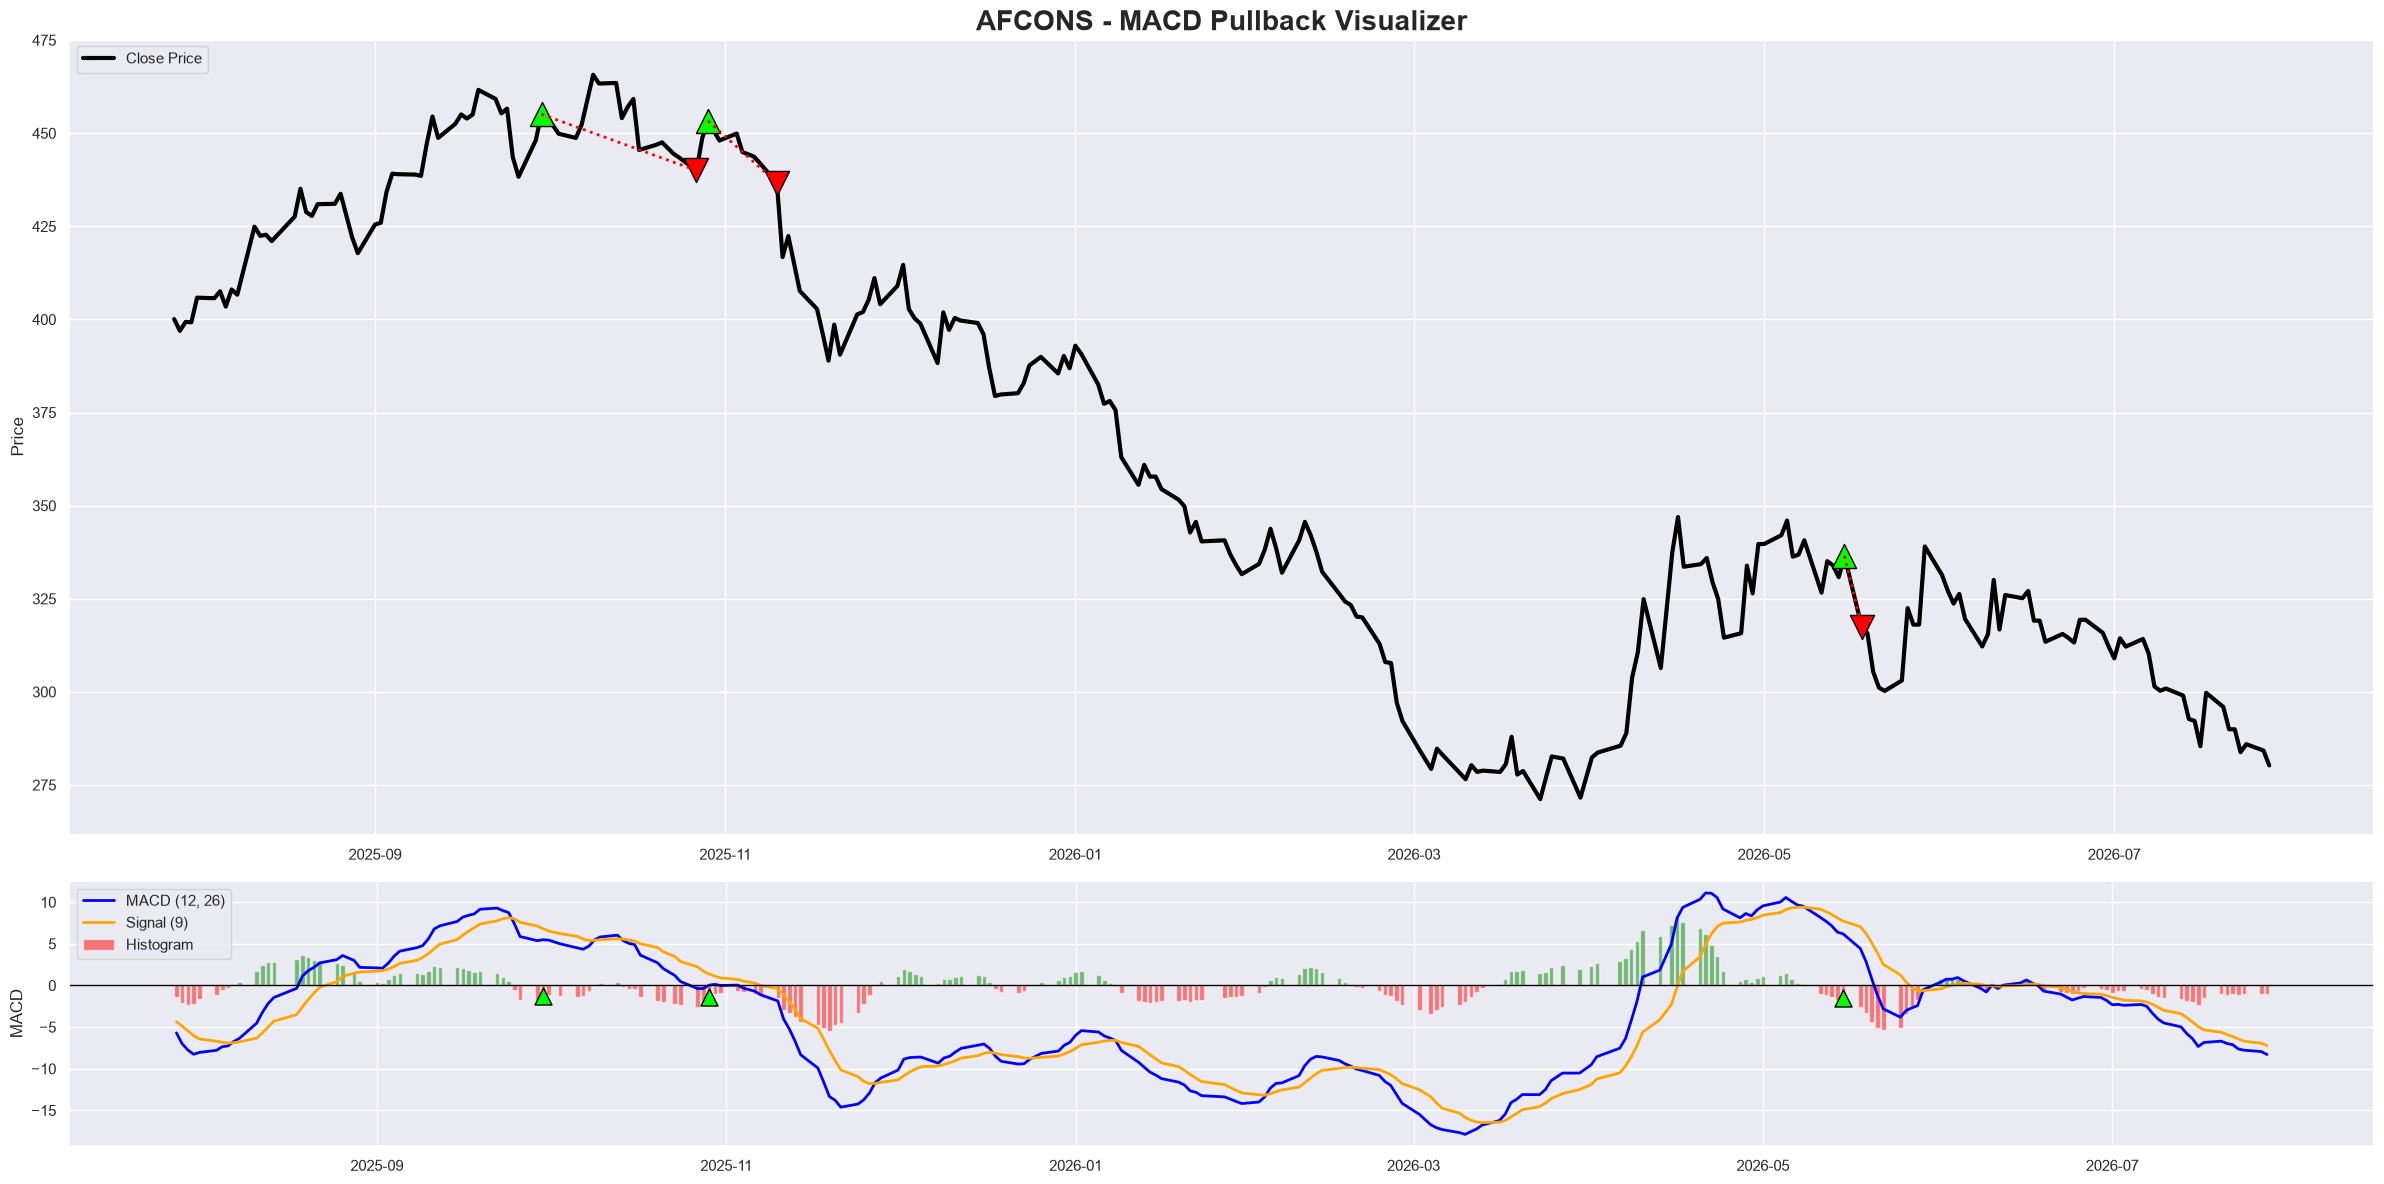

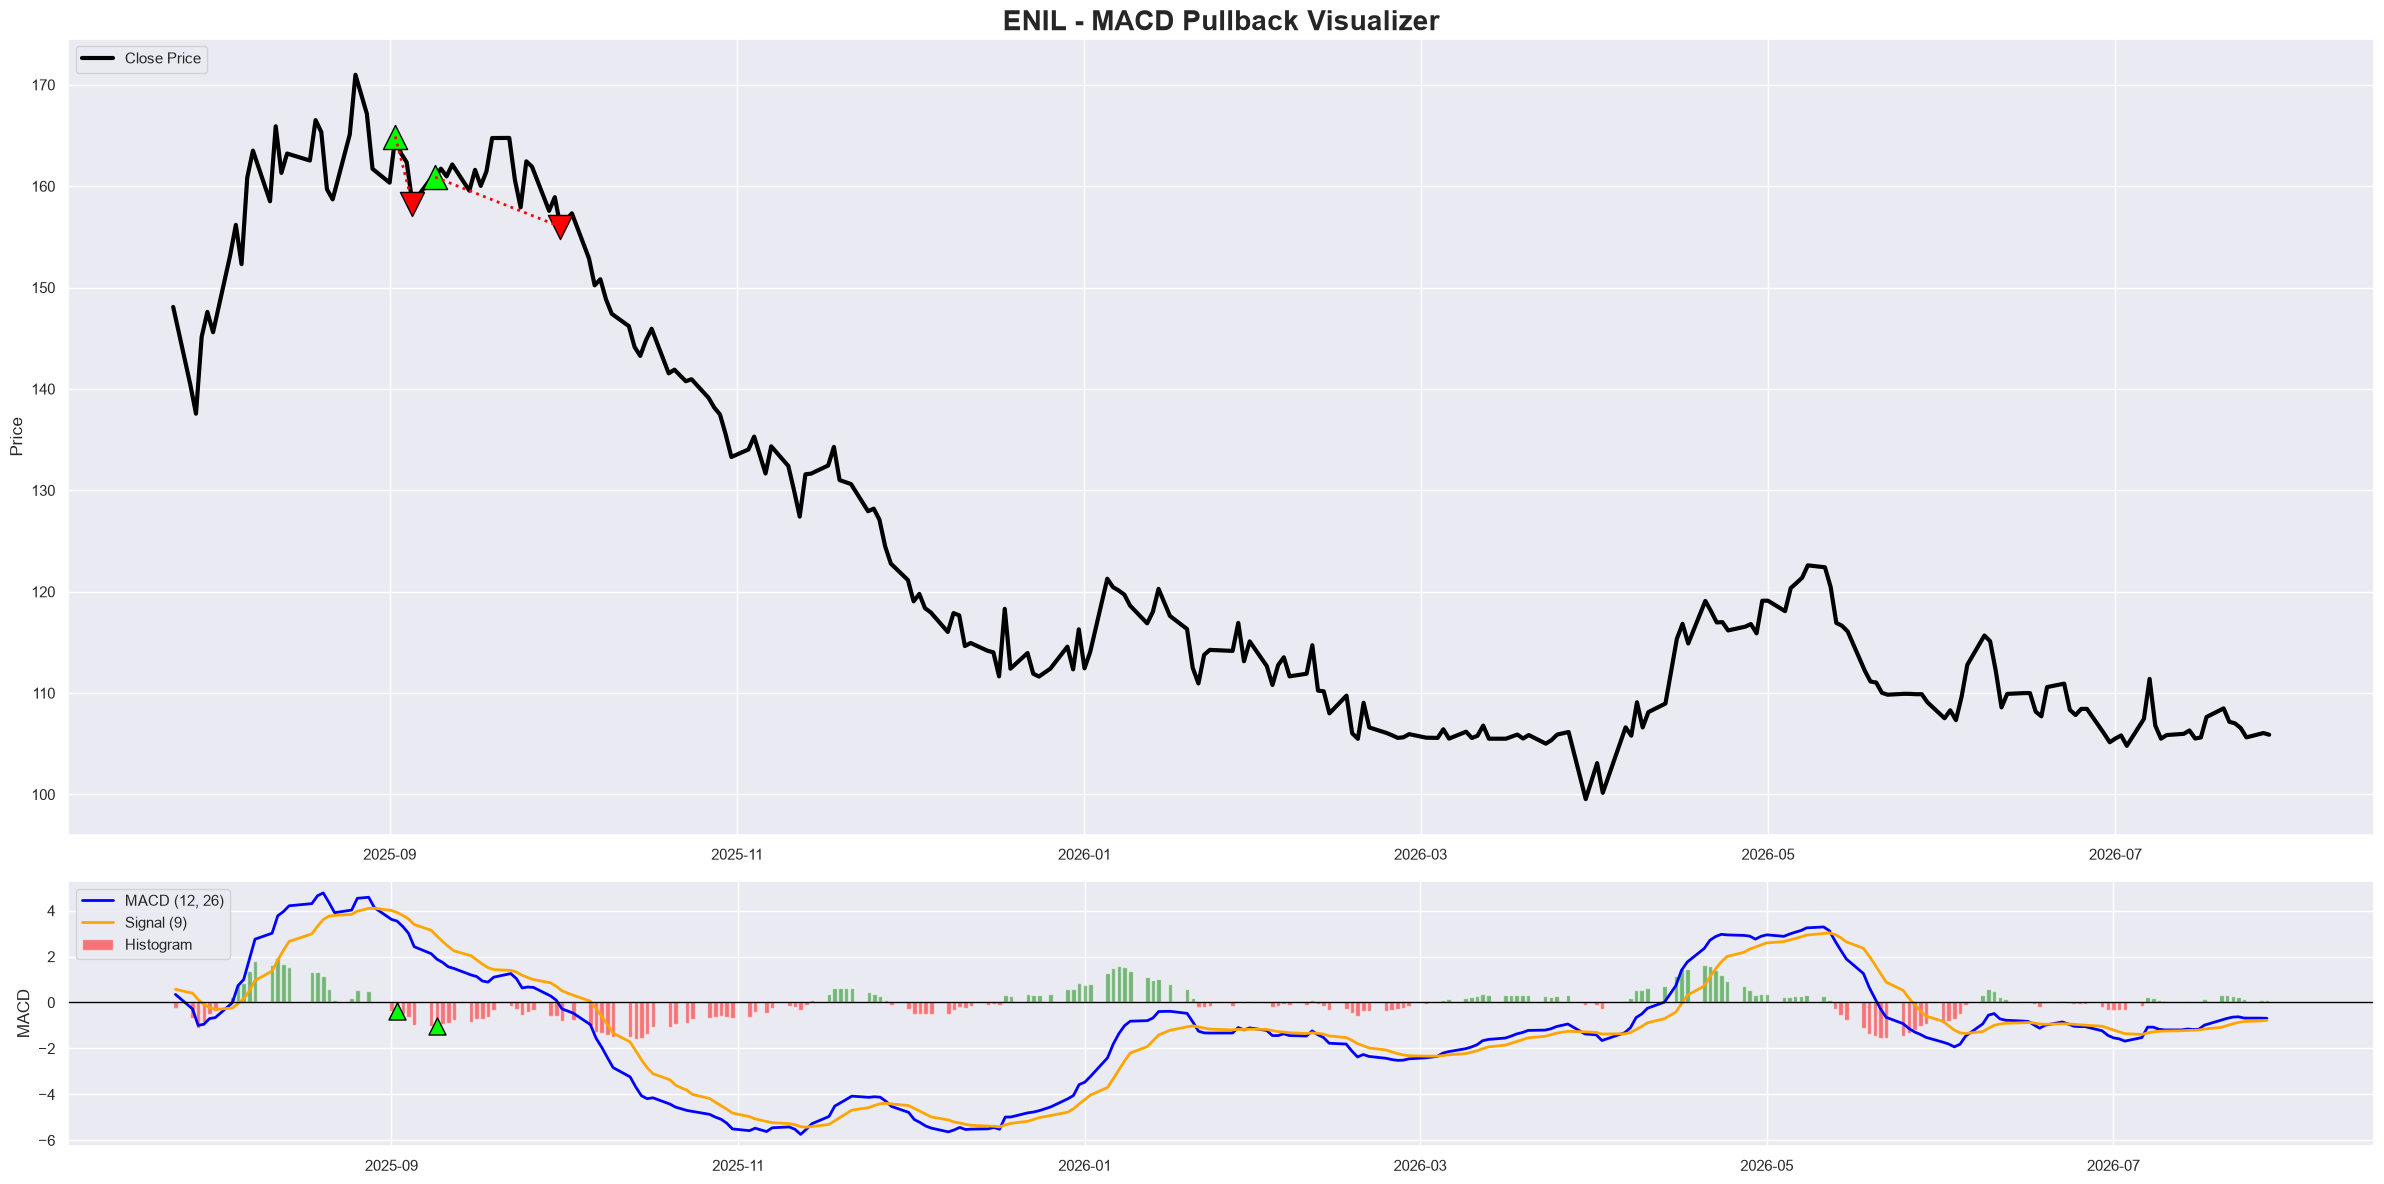

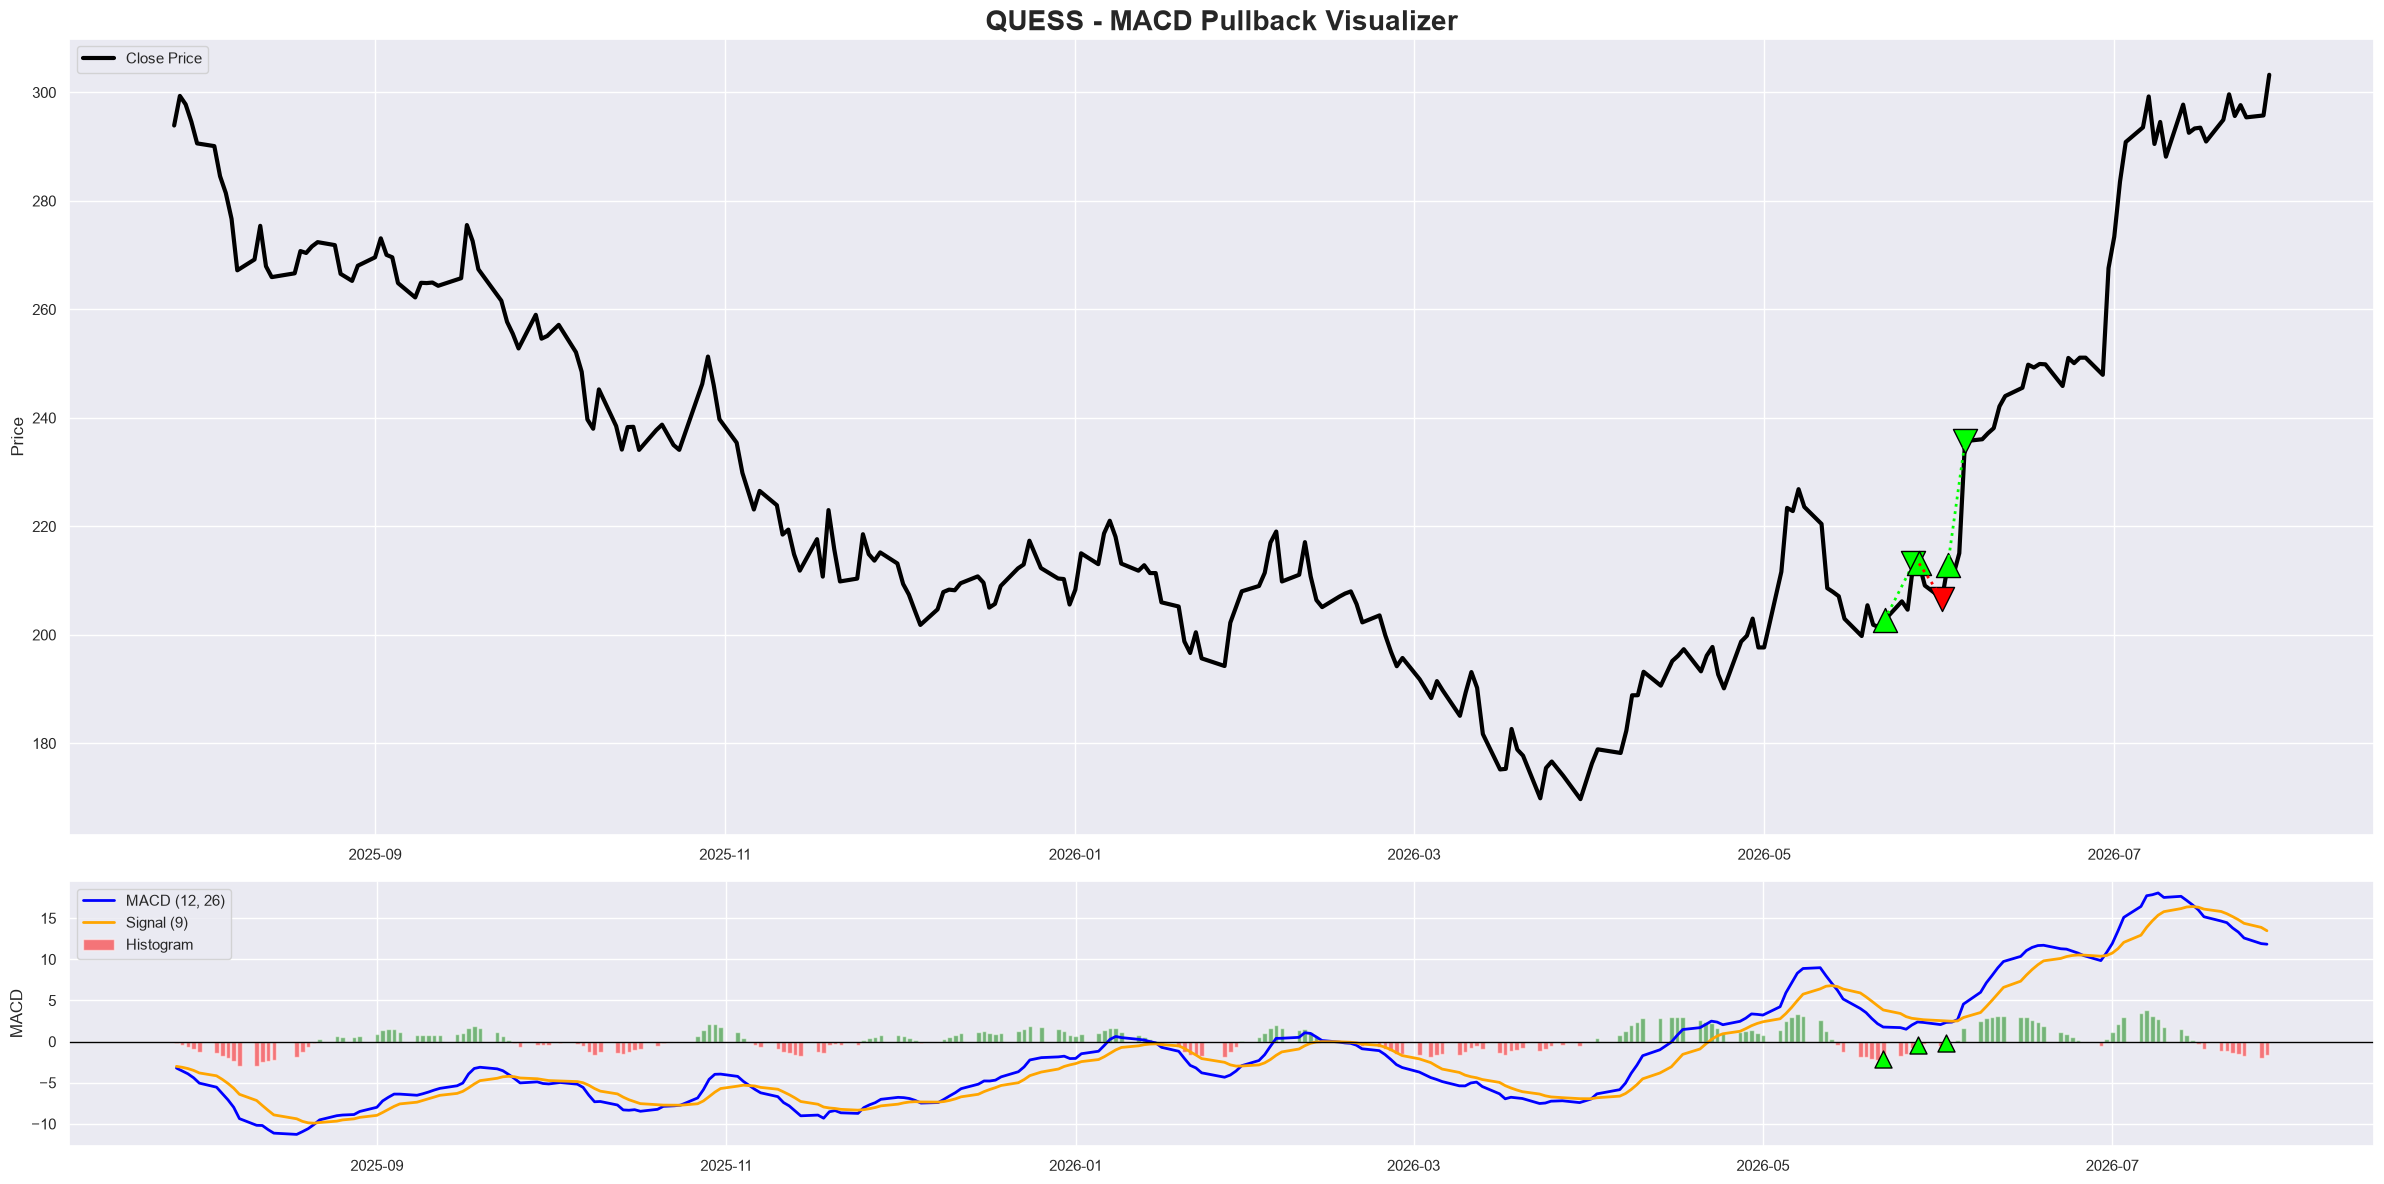

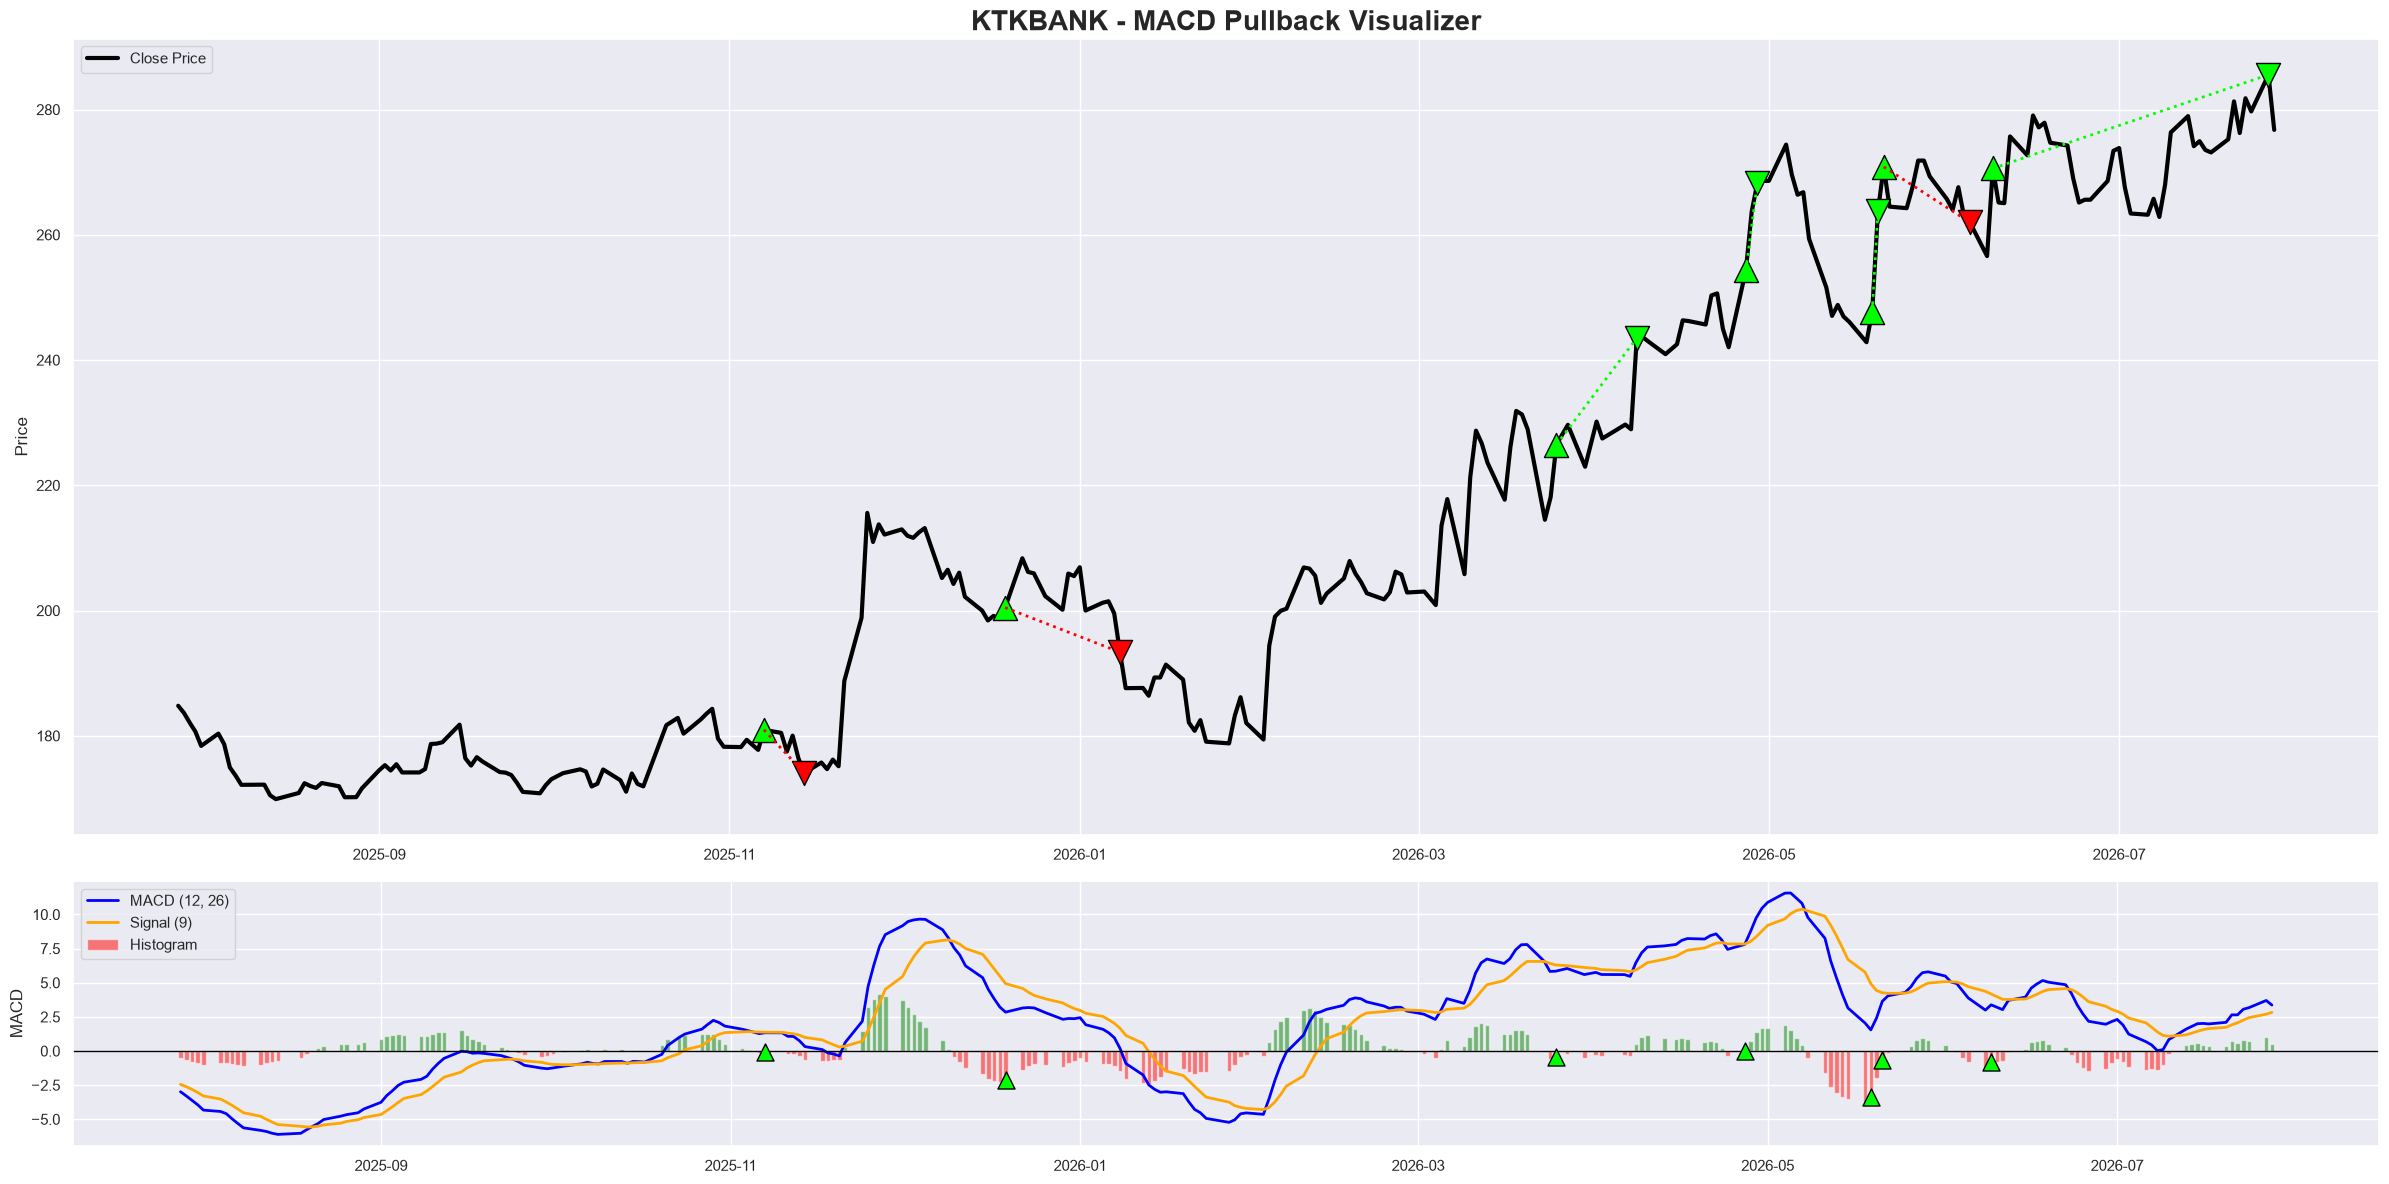

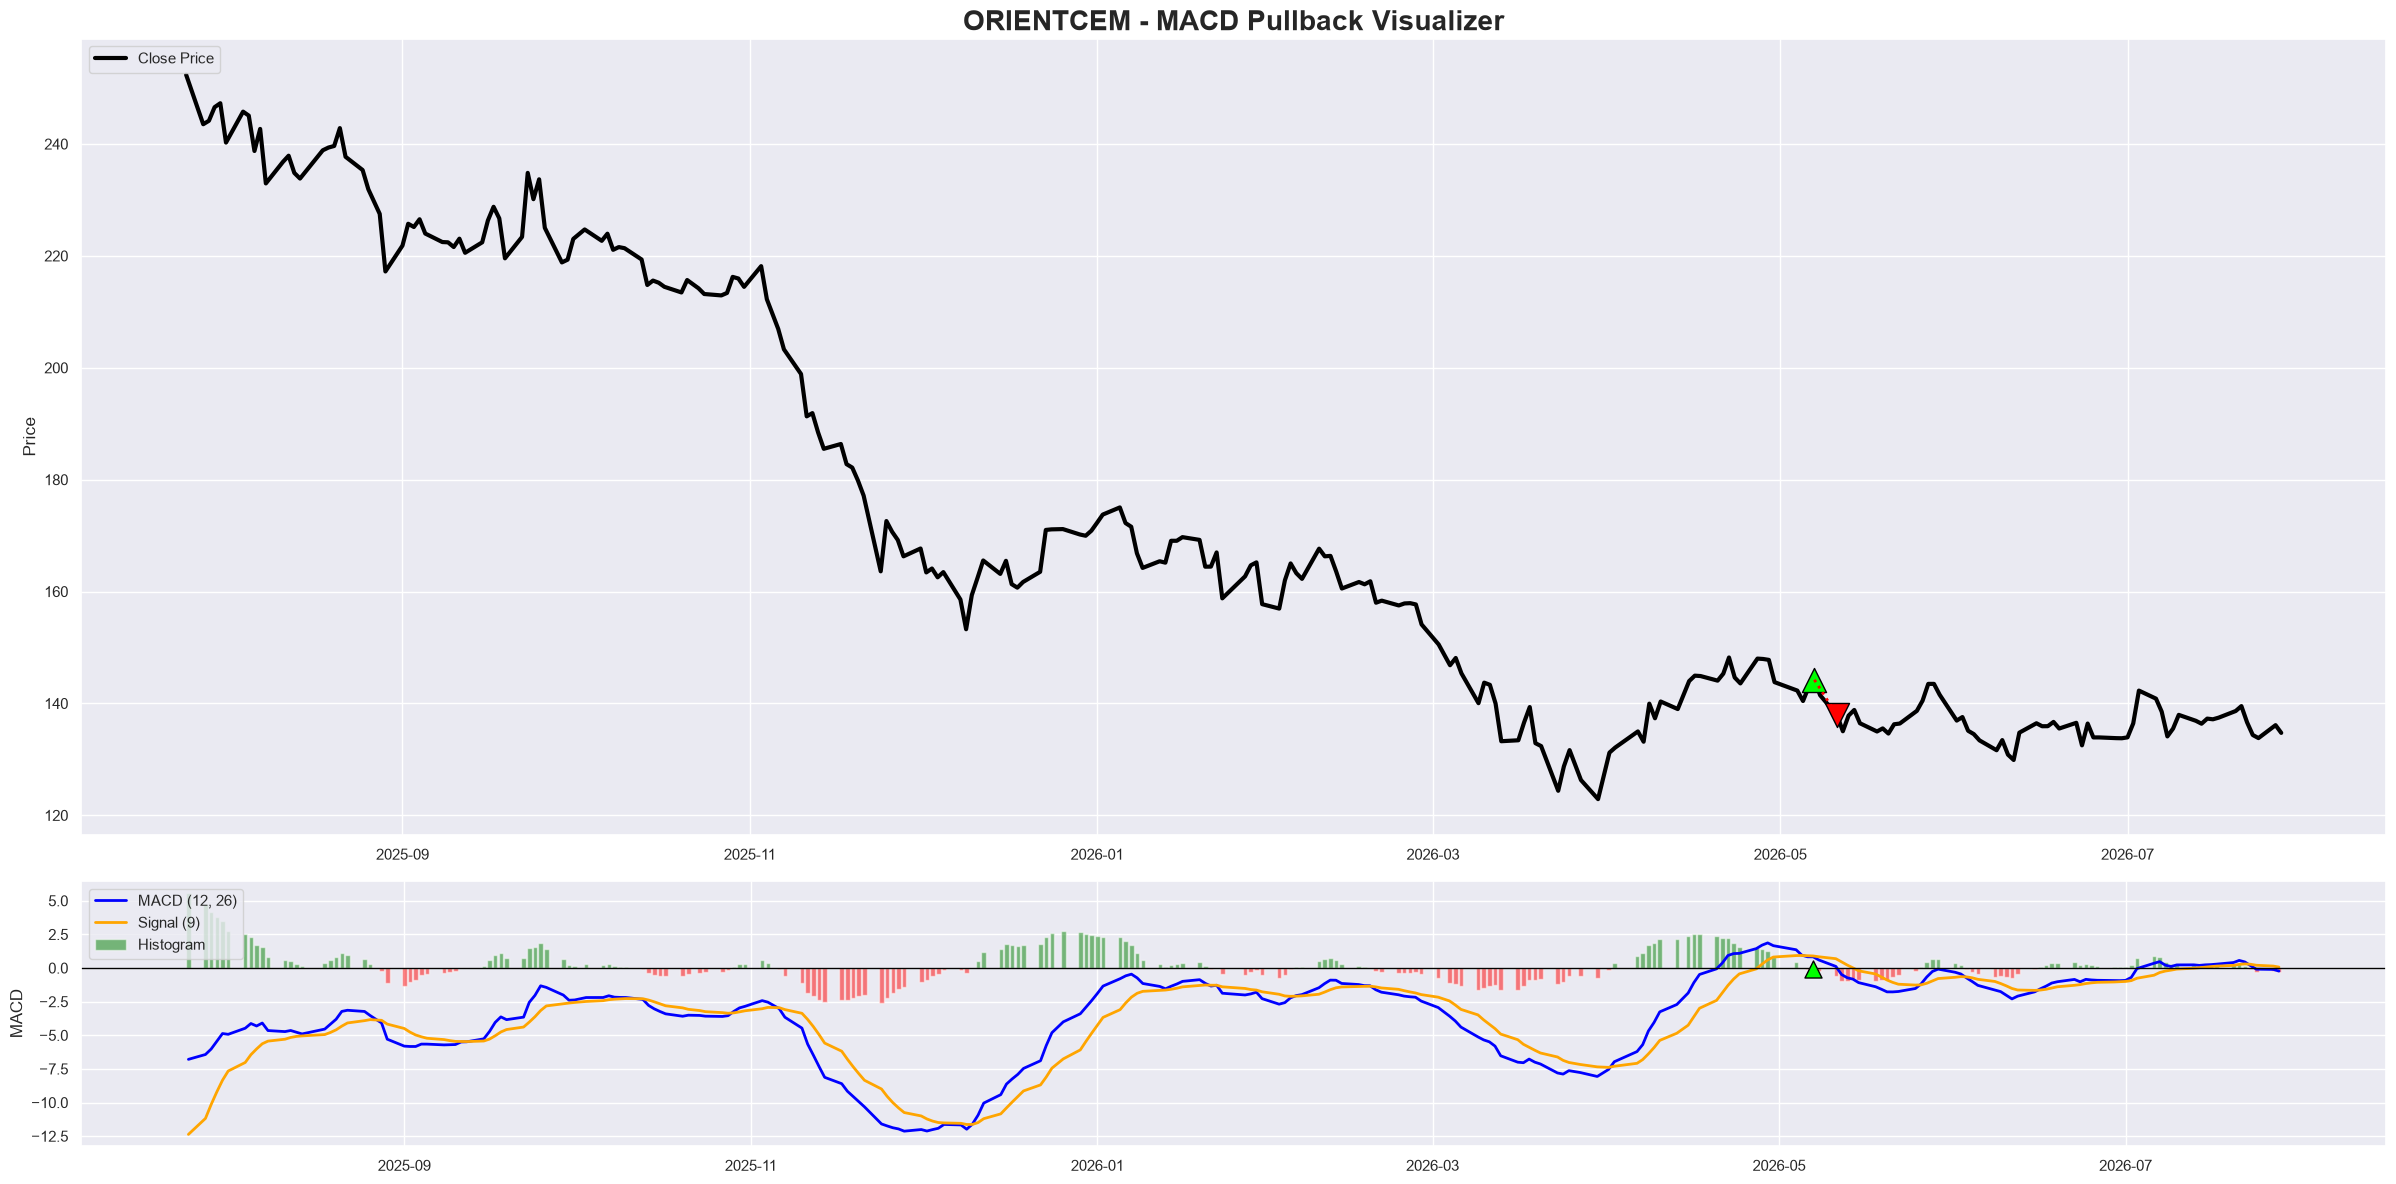

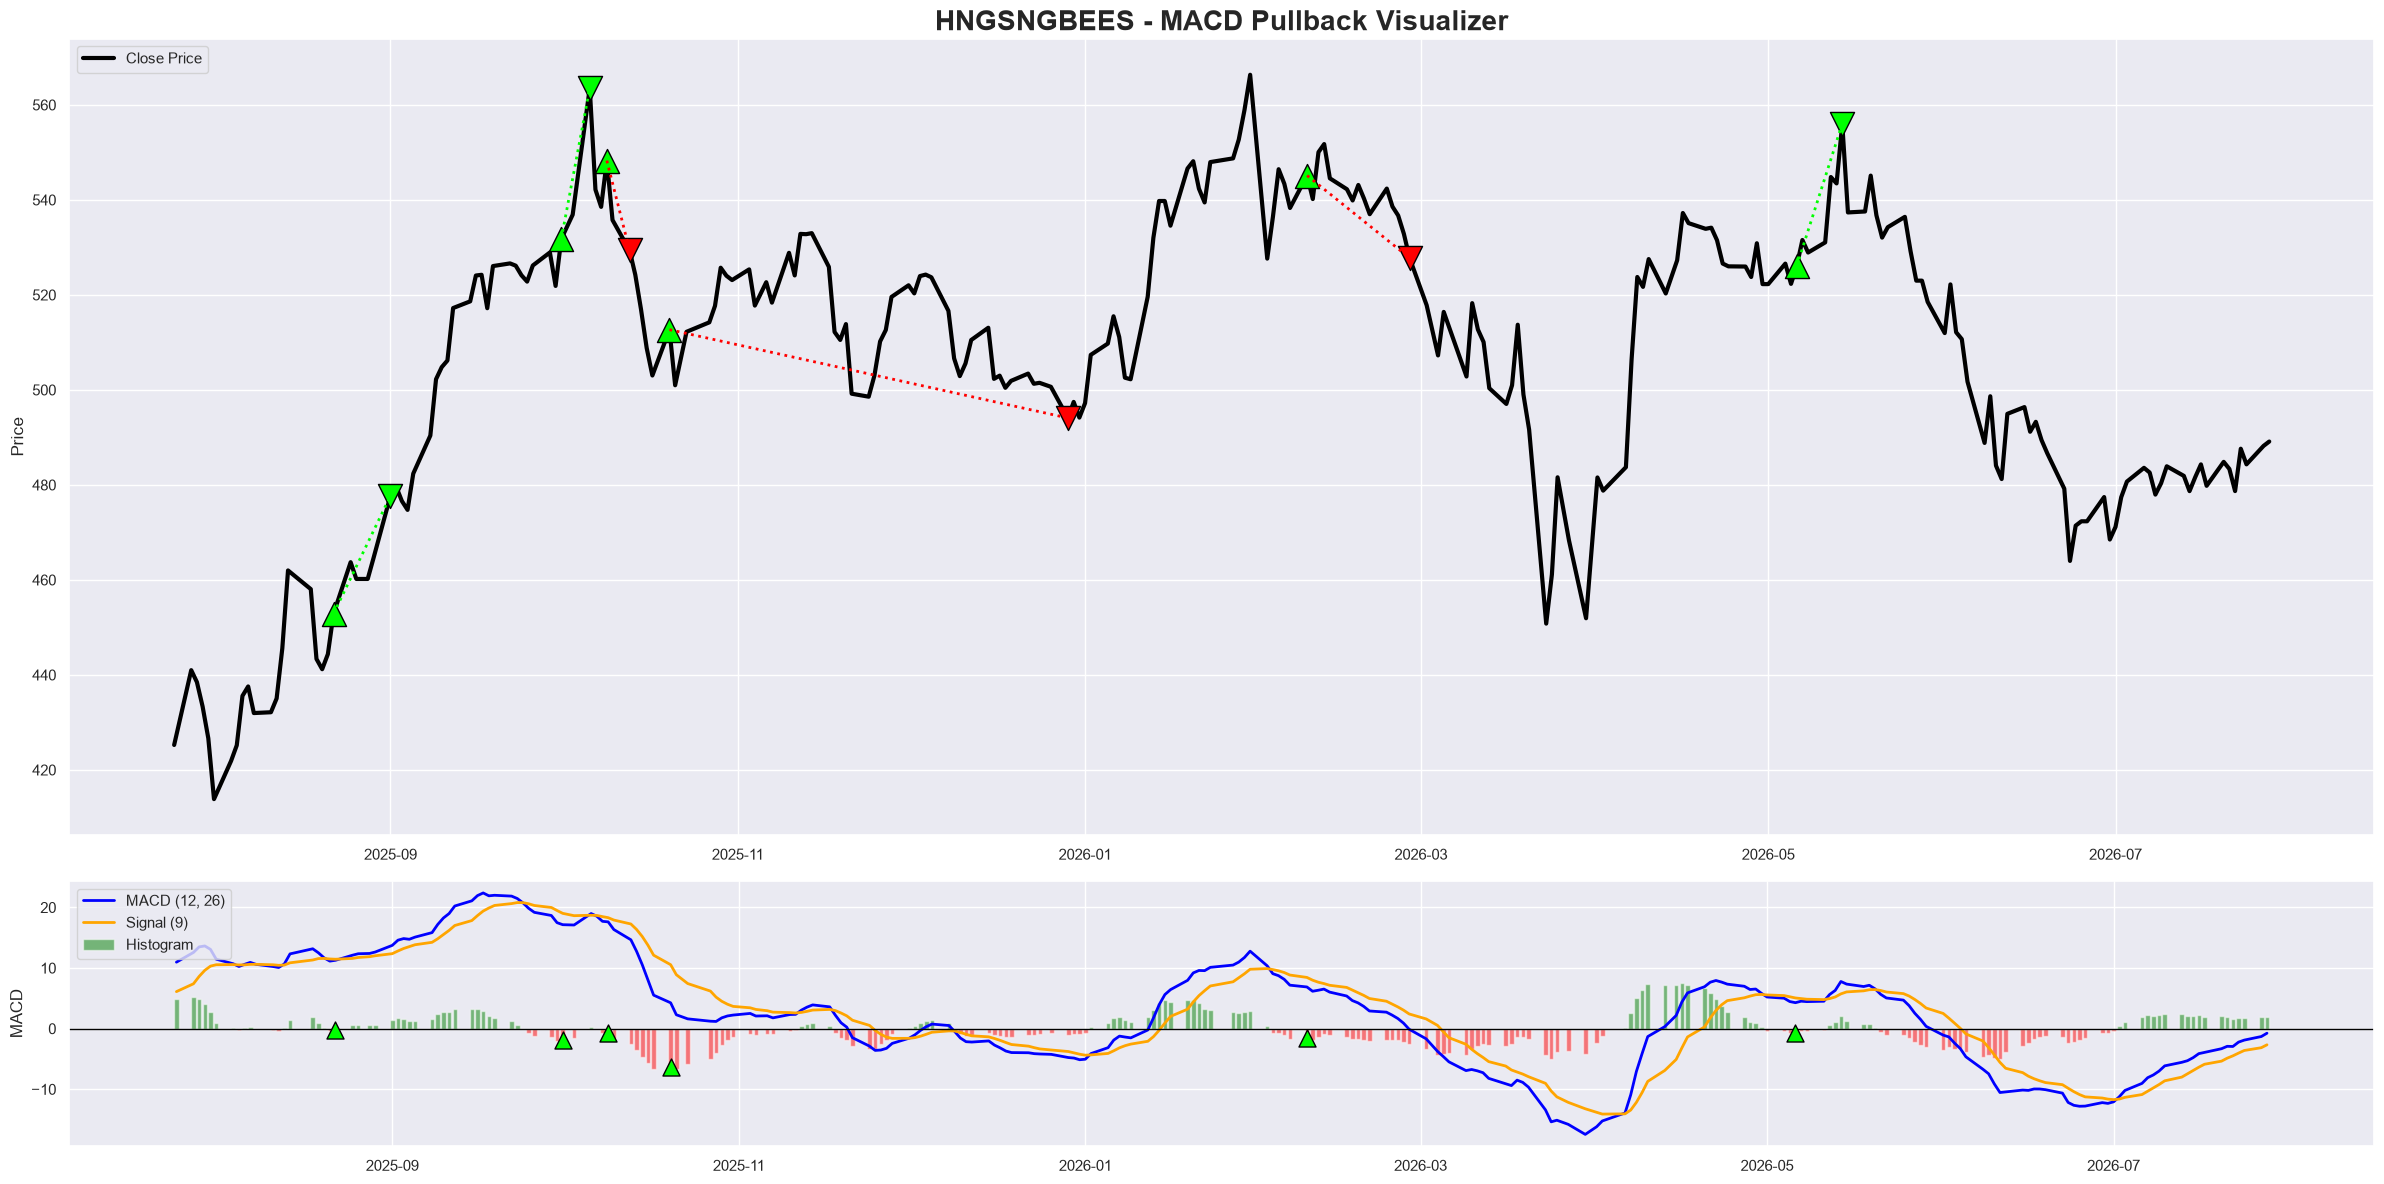

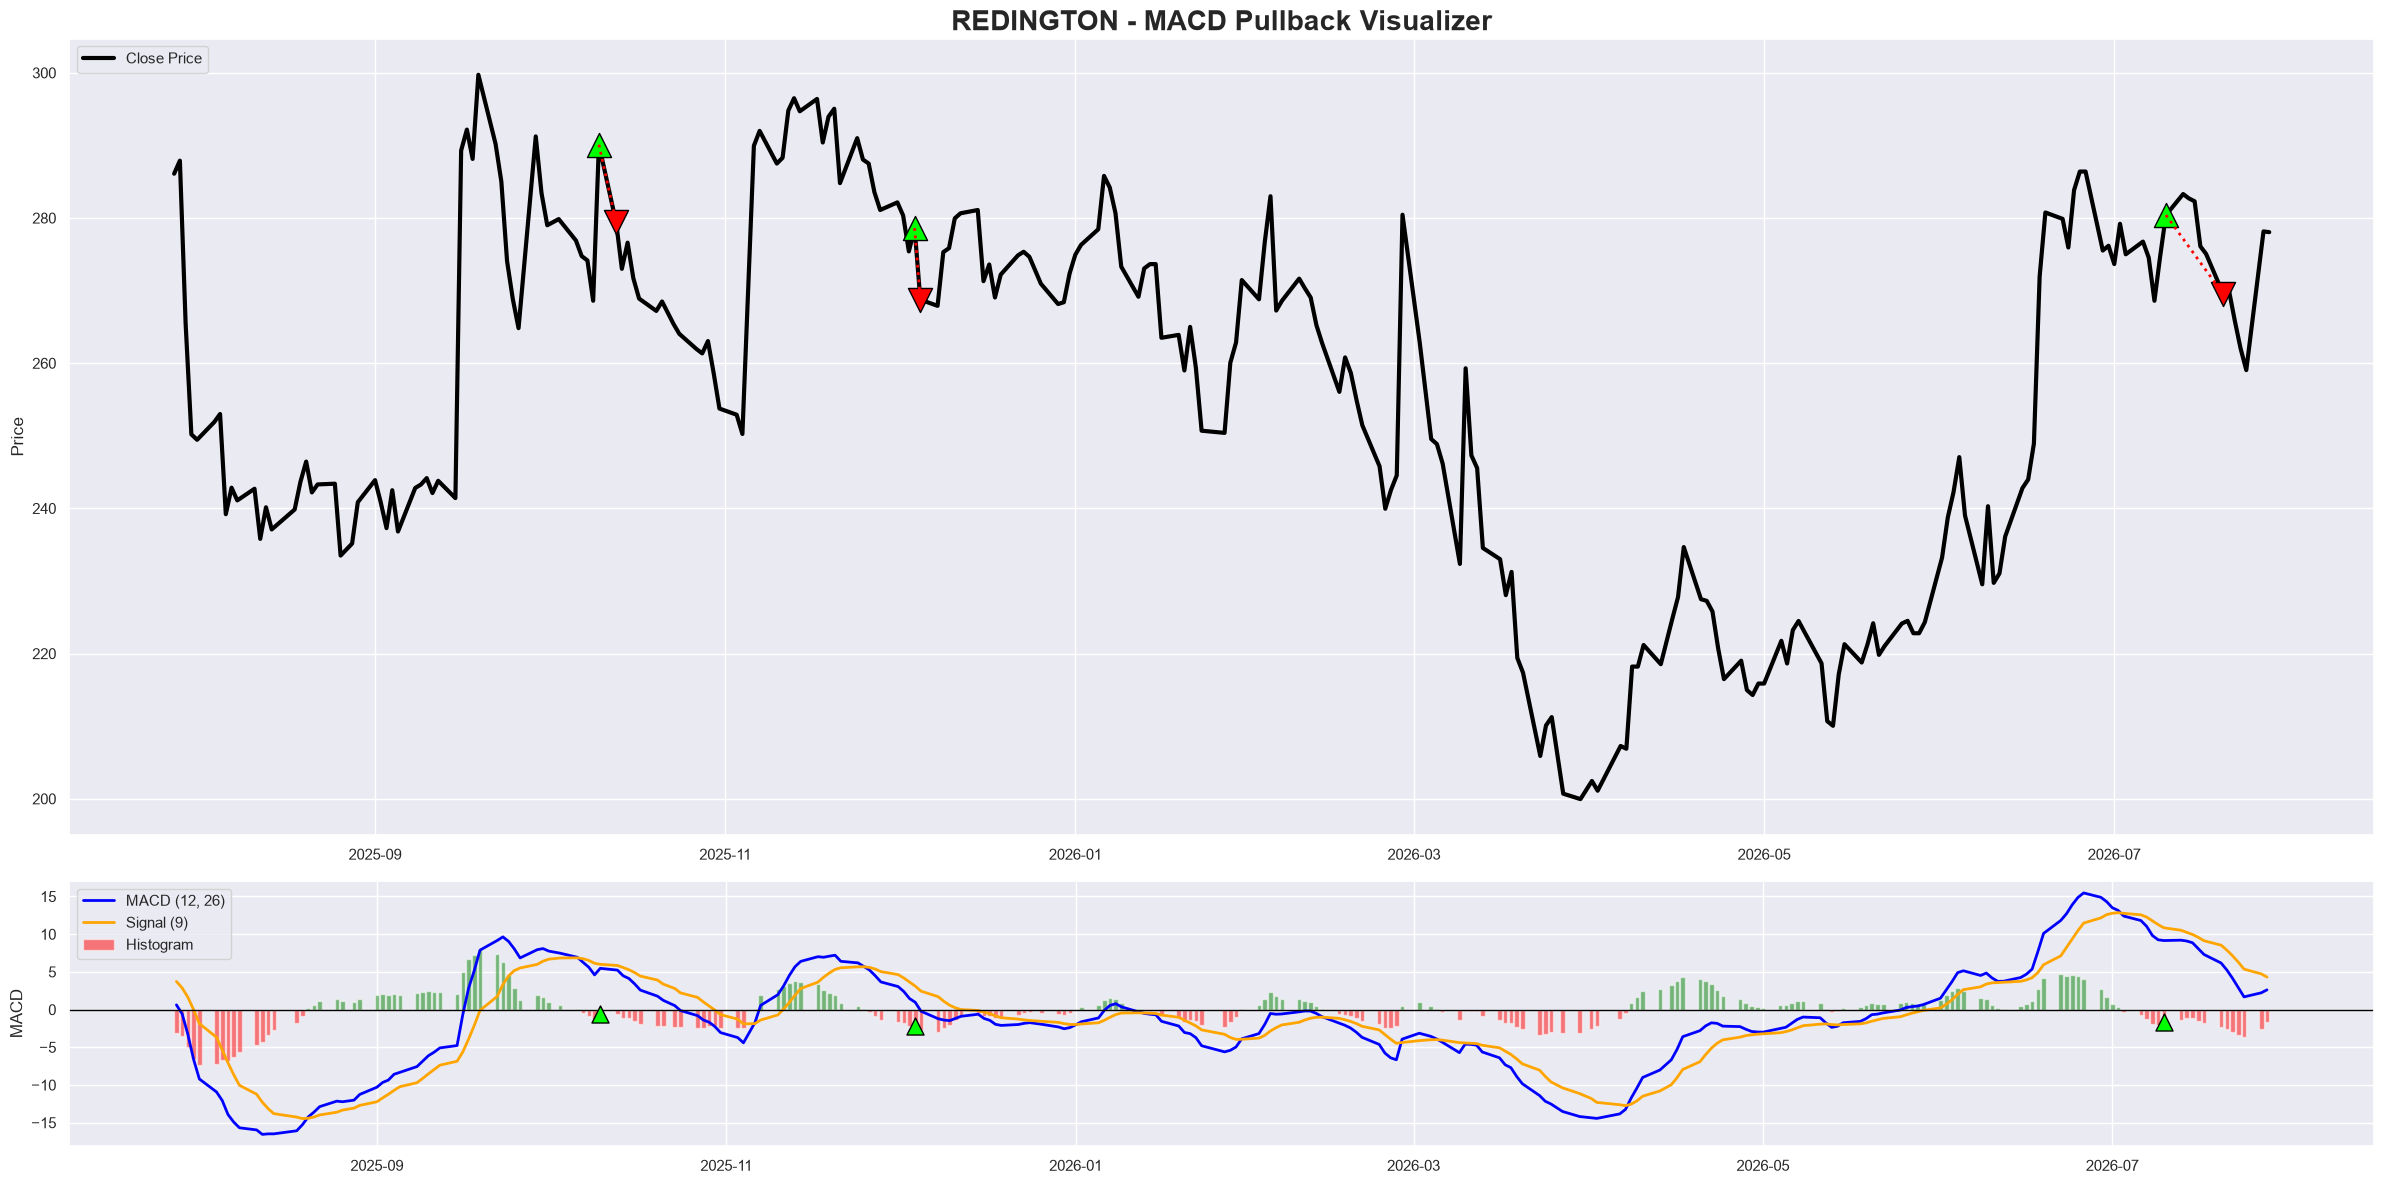

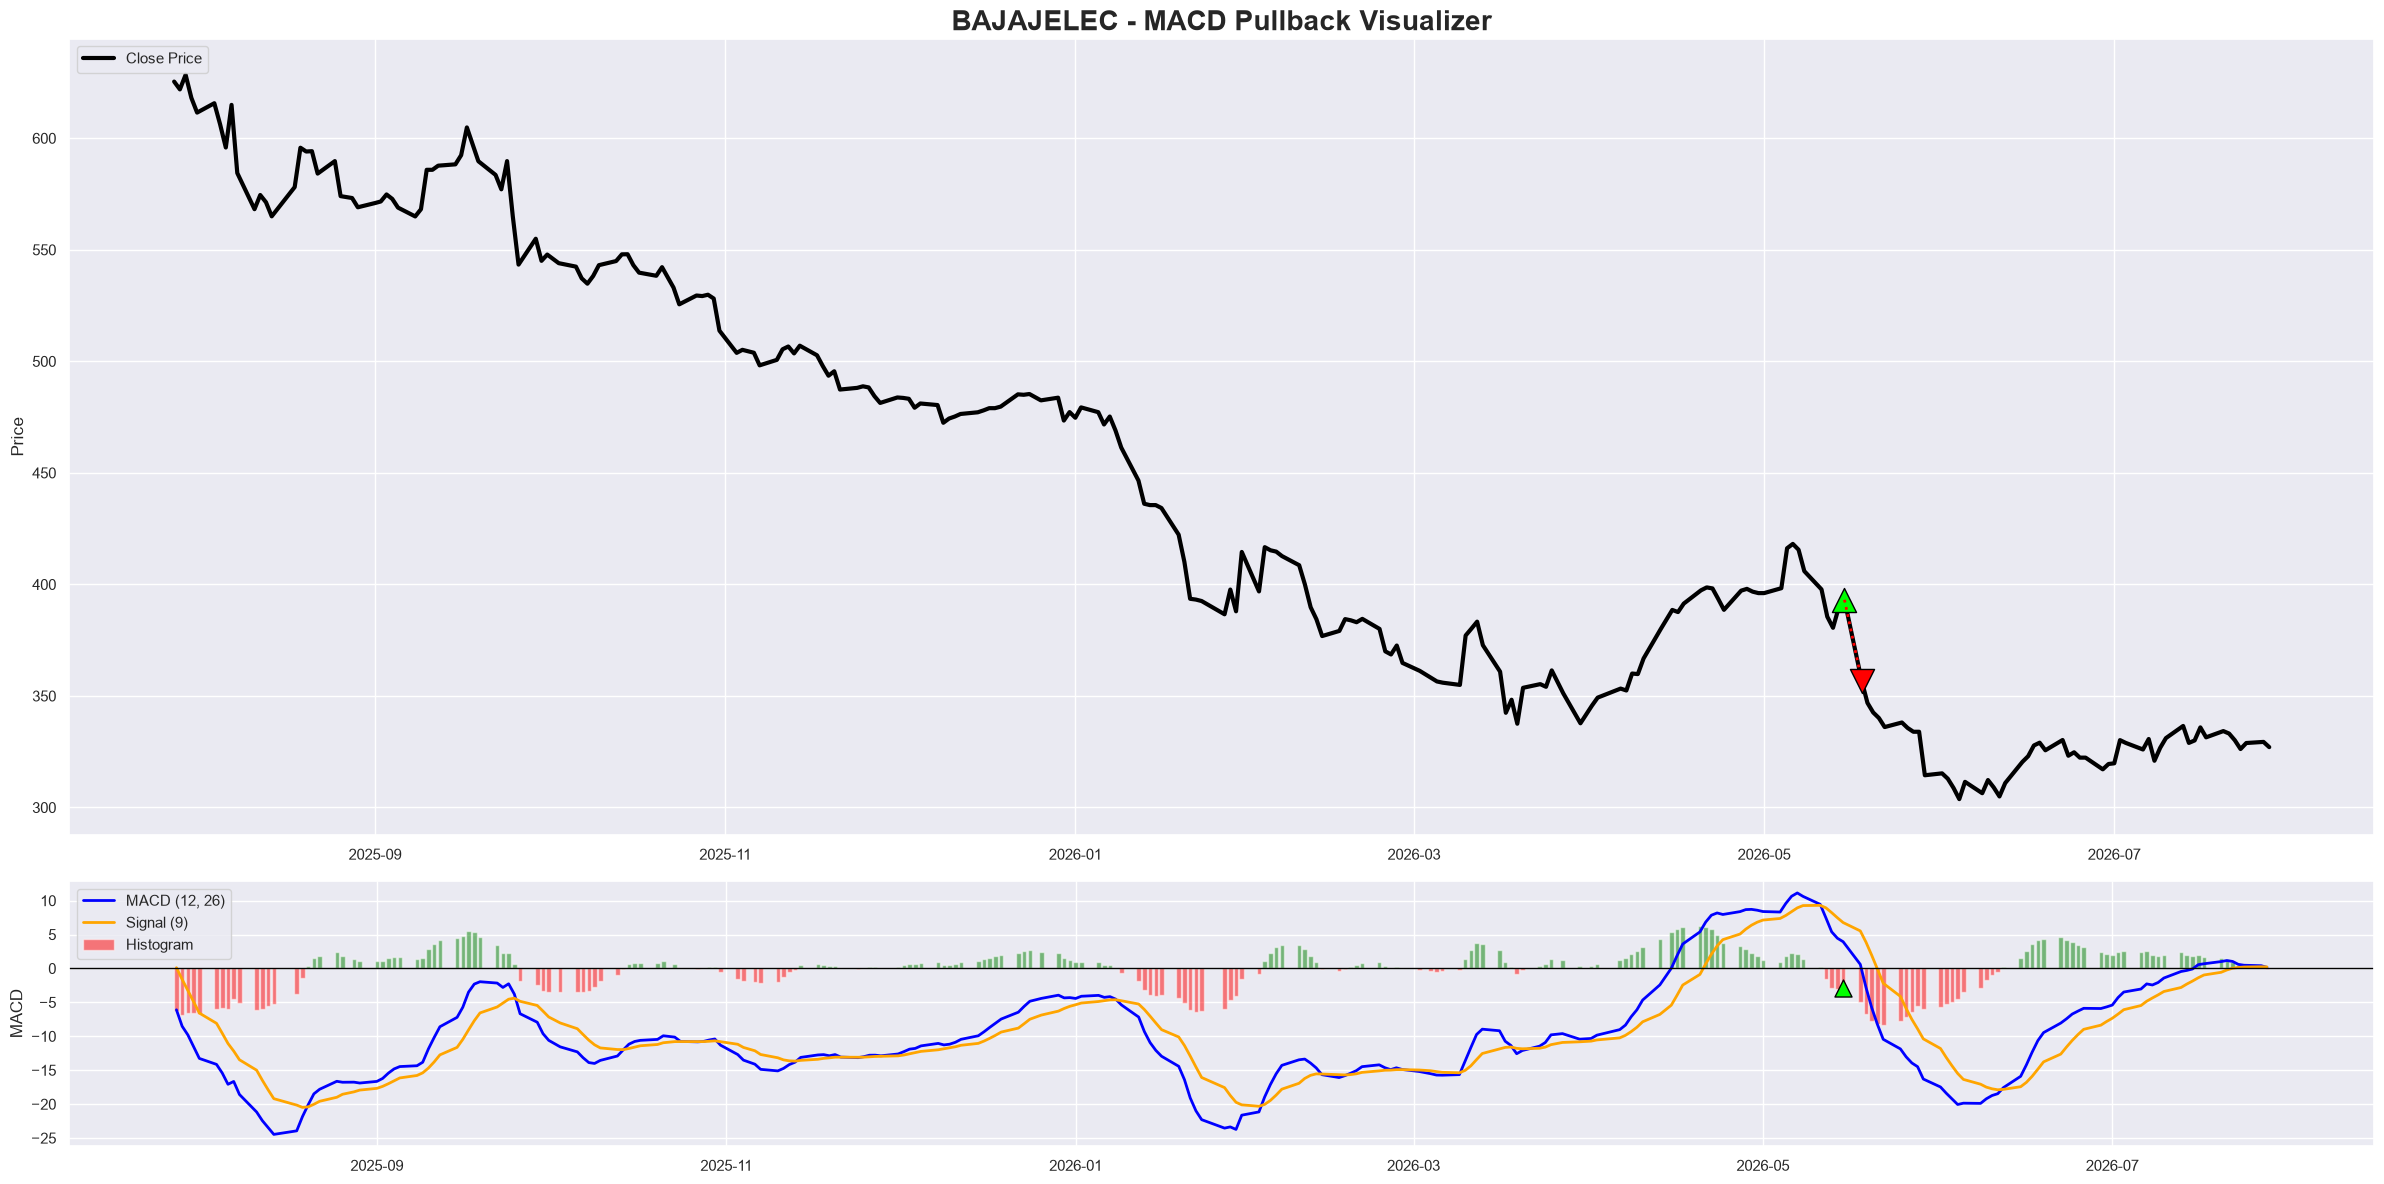

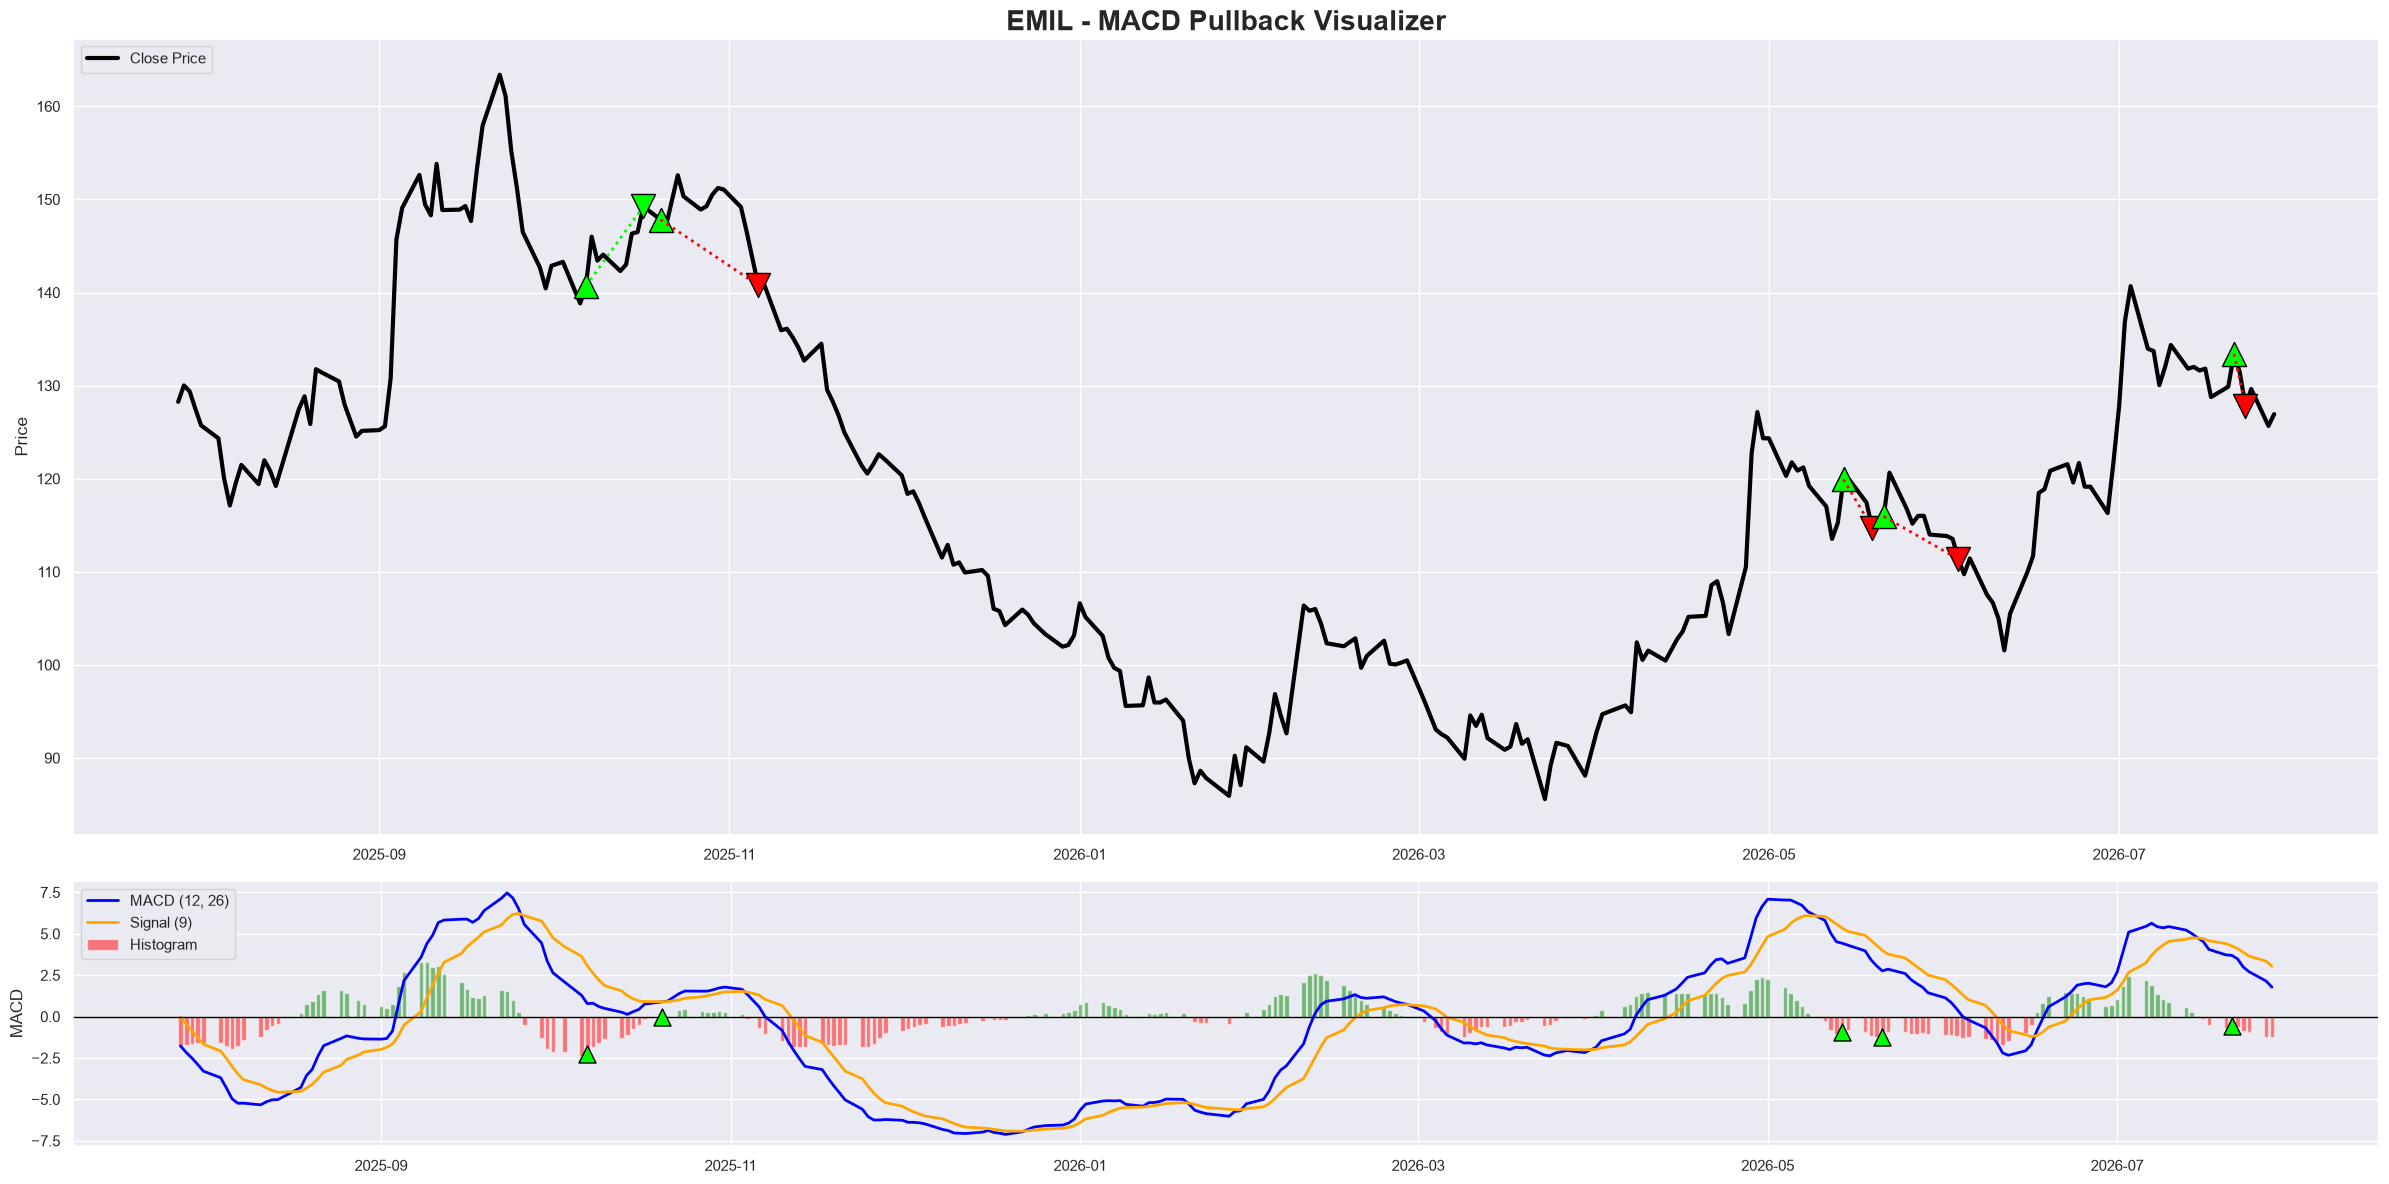

In [4]:
# 4. Visualizing the Trades
for symbol in symbols:
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 12), gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Plot: Price
    ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=3, zorder=5)
    ax1.set_title(f"{symbol} - MACD Pullback Visualizer", fontsize=20, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    
    # Bottom Plot: MACD
    ax2.plot(df['Date'], df['MACD'], label='MACD (12, 26)', color='blue', linewidth=2)
    ax2.plot(df['Date'], df['Signal'], label='Signal (9)', color='orange', linewidth=2)
    
    # Histogram colors (Green for UP, Red for DOWN)
    colors = ['green' if val > 0 else 'red' for val in df['Hist']]
    ax2.bar(df['Date'], df['Hist'], color=colors, alpha=0.5, label='Histogram')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_ylabel('MACD')
    ax2.legend(loc='upper left')
    
    # Plot Entries and Exits on Price Chart
    if len(trades_df) > 0:
        stock_trades = trades_df[trades_df['Symbol'] == symbol]
        for idx, trade in stock_trades.iterrows():
            ax1.scatter(trade['Entry_Date'], trade['Entry_Price'], color='lime', marker='^', s=300, zorder=6, edgecolors='black')
            exit_color = 'lime' if trade['Profit_Pct'] > 0 else 'red'
            ax1.scatter(trade['Exit_Date'], trade['Exit_Price'], color=exit_color, marker='v', s=300, zorder=6, edgecolors='black')
            ax1.plot([trade['Entry_Date'], trade['Exit_Date']], [trade['Entry_Price'], trade['Exit_Price']], color=exit_color, linestyle=':', linewidth=2, zorder=6)
            
            # Also mark the entry on the MACD chart to see the Histogram tick
            ax2.scatter(trade['Entry_Date'], df.loc[df['Date'] == trade['Entry_Date'], 'Hist'], color='lime', marker='^', s=150, zorder=6, edgecolors='black')
    
    plt.tight_layout()
    plt.show()
